## 1. Introduction et Description de la base de données :
**1- Introduction :**
Ce projet porte sur l'analyse et la modélisation d'un jeu de données de charges médicales individuelles aux États Unis dont le but est de prédire le montant des charges médicales (charges) facturées à un individu en fonction de ses caractéristiques personnelles (âge, sexe, IMC, nombre d'enfants, statut fumeur, région géographique). <br>
**2- Description de la base de données :** <br>
Nom du fichier : medical-charges.csv <br>
Nombre d'observations : 1339 <br>
Nombre de variables : 7 (6 features + 1 target) <br>
<table>
  <tr>
    <th>Variable</th>
    <th>Type</th>
    <th>Description</th>
    <th>Valeurs possibles</th>
  </tr>
  <tr>
    <td>age</td>
    <td> Numérique</td>
    <td>Âge du bénéficiaire principal</td>
    <td>18 – 64 ans</td>
  </tr>
  <tr>
    <td>sexe</td>
    <td>Catégorielle</td>
    <td>Sexe du bénéficiaire</td>
    <td>female , male</td>
  </tr>
  <tr>
    <td>bmi</td>
    <td>Numérique</td>
    <td> Indice de Masse Corporelle (Body Mass Index)</td>
    <td>Valeur continue (ex: 15.96 – 53.13)</td>
  </tr>
  <tr>
    <td>children</td>
    <td>Numérique</td>
    <td>Nombre d'enfants / dépendants couverts par l'assurance</td>
    <td>0 – 5</td>
  </tr>
  <tr>
    <td>smoker</td>
    <td>Catégorielle</td>
    <td>Le bénéficiaire est-il fumeur ?</td>
    <td>yes , no</td>
  </tr>
  <tr>
    <td>region</td>
    <td>Catégorielle</td>
    <td>Zone résidentielle du bénéficiaire aux États-Unis</td>
    <td>southwest , southeast , northwest , northeast</td>
  </tr>
  <tr>
    <td>charges</td>
    <td> Numérique</td>
    <td>Charges médicales individuelles facturées par l'assurance  (variable cible)</td>
    <td>Valeur continue (ex: 1121 – 63 770)</td>
  </tr>
</table>


## 2. Importation des Librairies

In [ ]:
import pandas as pd
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## 3. Chargement des données

In [ ]:
# Importation du dataframe
df = pd.read_csv("/content/sample_data/medical-charges.csv")
# Aperçu des premières lignes
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**df.head()** permet d'afficher les premières lignes de la base de données .

In [ ]:
# Aperçu des dernières lignes
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


**df.tail()** permet d'afficher les dernières lignes de la base de données .

In [ ]:
# Dimensions du dataset
df.shape

(1338, 7)

**df.shape()** permet d'afficher les dimension de la base de données dont 1338 désigne le nombre d'observations et 7 désigne le nombre de variables .

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**df.info()** permet d'afficher un résumé des caracteristiques de la base de données. <br>
**1- RangeIndex:** 1338 entries, 0 to 1337 c'est à dire 1338 lignes notées de 0 à 1337 . <br>
**2- Data columns (total 7 columns)** c'est à dire la base de données contient 7 colonnes. <br>
**3- Le tableau au dessous** Donne les noms des colonnes, le nombre de valeurs non nulles pour chacune, ainsi que leur type de données (int64, float64, object). <br>
**4- memory usage: 73.3+ KB** signifie la mémoire utilisée par le DataFrame .

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**df.describe()** permet de fournir des statistiques descriptives sur les colonnes numériques .
<table>
  <tr>
    <th>Statistique</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>count</td>
    <td> Nombre de valeurs non nulles</td>
    
  </tr>
  <tr>
    <td>mean</td>
    <td>Moyenne</td>
    
  </tr>
  <tr>
    <td>std</td>
    <td>Écart-type</td>
    
  </tr>
  <tr>
    <td>min</td>
    <td>Valeur minimale</td>
    
  </tr>
  <tr>
    <td>25%</td>
    <td>1er quartile (25ème percentile)</td>
    
  </tr>
  <tr>
    <td>50%</td>
    <td>Médiane (50ème percentile)</td>
    
  </tr>
  <tr>
    <td>75%</td>
    <td>3ème quartile (75ème percentile)</td>
  </tr>
   <tr>
    <td>max</td>
    <td>Valeur maximale</td>
  </tr>
</table>

#### Vérification des types de données

In [ ]:
# Types de données
print("\n📊 Types de données :")
print(df.dtypes.value_counts())
print("\n--- Détail ---")
df.dtypes


📊 Types de données :
object     3
int64      2
float64    2
Name: count, dtype: int64

--- Détail ---


,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


**df.dtypes.value_counts()** Compte le nombre de colonnes pour chaque type de données. <br>
**df.dtypes** Renvoie le type de données de chaque colonne de la base de données.

In [ ]:
# Statistiques descriptives - Variables catégorielles
print("\n📊 Variables catégorielles :")
for col in df.select_dtypes(include='object').columns:
    print(f"\n  {col} : {df[col].nunique()} valeurs uniques")
    print(f"    Top 5 : {df[col].value_counts().head().to_dict()}")


📊 Variables catégorielles :

  sex : 2 valeurs uniques
    Top 5 : {'male': 676, 'female': 662}

  smoker : 2 valeurs uniques
    Top 5 : {'no': 1064, 'yes': 274}

  region : 4 valeurs uniques
    Top 5 : {'southeast': 364, 'southwest': 325, 'northwest': 325, 'northeast': 324}


**df[col].nunique** permet d'afficher les valeurs uniques dans une colonne. <br>
**df[col].value_counts().head().to_dict()** Compte le nombre de fois que chaque valeur unique apparaît dans la colonne.

In [ ]:
# Valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Manquantes', ascending=False)

if len(missing_df) == 0:
    print("✅ Aucune valeur manquante (NaN) dans le dataset.")
else:
    print("⚠️ Valeurs manquantes détectées :")
    display(missing_df)

✅ Aucune valeur manquante (NaN) dans le dataset.


## 4. Analyse Exploratoire des données (EDA)

### 4.1 Analyse Univariée

#### Distribution de chaque variable numérique

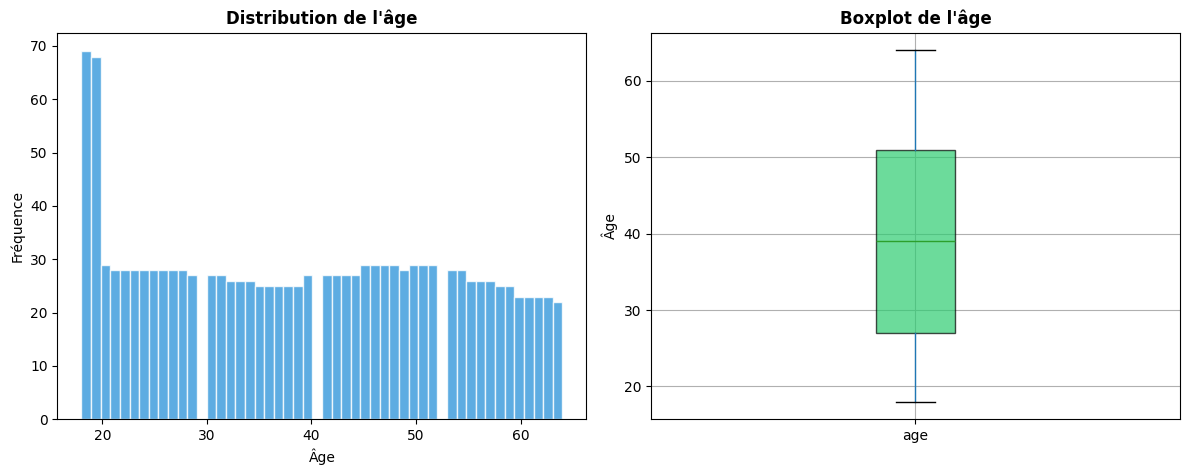

In [ ]:
# Distribution de la variable Age :
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Histogramme
axes[0].hist(df['age'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution de l'âge", fontweight='bold')
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Fréquence")

# 🔹 Boxplot
df.boxplot(column='age', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.7))

axes[1].set_title("Boxplot de l'âge", fontweight='bold')
axes[1].set_ylabel("Âge")
axes[1].set_xlabel("")

# Enlever le titre automatique
plt.suptitle('')

plt.tight_layout()
plt.show()


**L'histogramme de distribution de la variable âge** montre que la fréquence des individus agés entre 18 et 20 est importante presentant un pic trés marqué, puis la répartition des âges est presque uniforme de 20 à 60 ans .
<br>
**Le Boxplot de la variable âge** montre que la majorité des âges sont concentrés entre 27 et 51 ans (IQR), les extrêmes sont 18 et 64 ans et la distribution est légèrement asymétrique vers les jeunes ce qui est conforme avec l'histogramme .

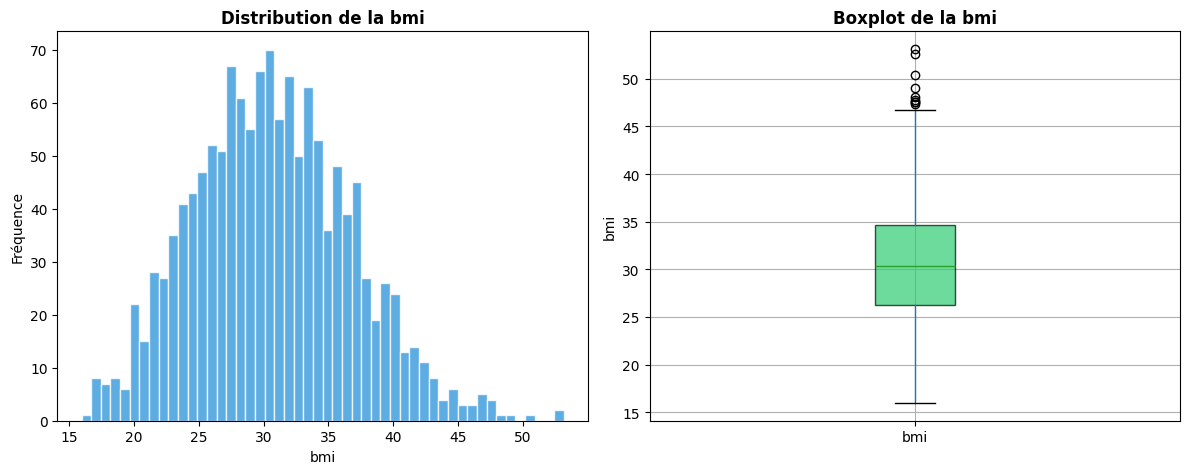

In [ ]:
# Distribution de la variable bmi :
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Histogramme
axes[0].hist(df['bmi'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution de la bmi", fontweight='bold')
axes[0].set_xlabel("bmi")
axes[0].set_ylabel("Fréquence")

# 🔹 Boxplot
df.boxplot(column='bmi', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.7))

axes[1].set_title("Boxplot de la bmi", fontweight='bold')
axes[1].set_ylabel("bmi")
axes[1].set_xlabel("")

# Enlever le titre automatique
plt.suptitle('')

plt.tight_layout()
plt.show()


**L'histogramme de distribution de la variable bmi** montre que la majorité des individus presente un indice de Masse Corporelle entre 25 et 38 . <br>
**Le Boxplot de la variable bmi** montre que la majorité des valeurs de la bmi sont concentrées entre 26 et 35 ans (IQR), les extrêmes sont 16 et 47 ans et on remarque l'existance des outliers (valeurs abérantes) aprés l'extrême superieur (47) .

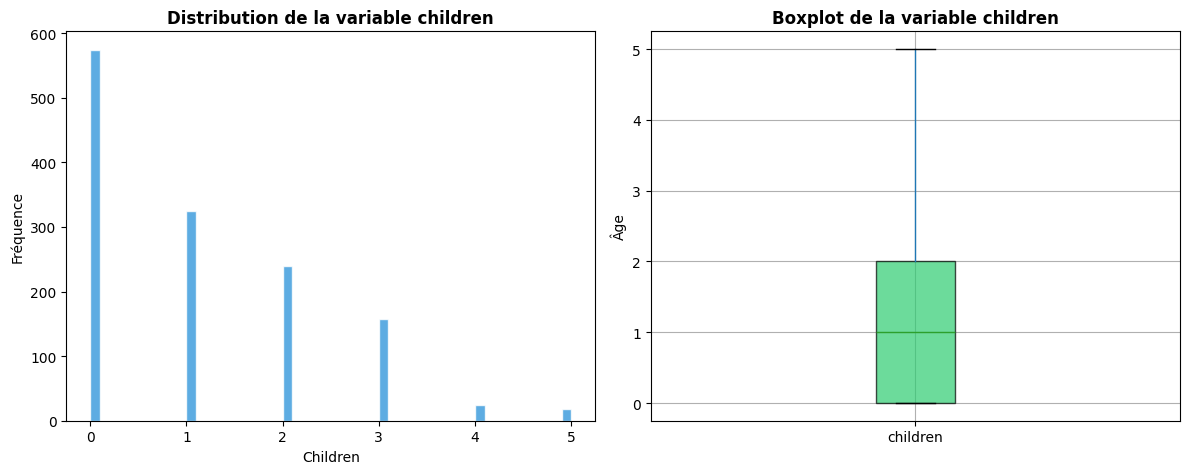

In [ ]:
# Distribution de la variable Children :
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Histogramme
axes[0].hist(df['children'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution de la variable children", fontweight='bold')
axes[0].set_xlabel("Children")
axes[0].set_ylabel("Fréquence")

# 🔹 Boxplot
df.boxplot(column='children', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.7))

axes[1].set_title("Boxplot de la variable children", fontweight='bold')
axes[1].set_ylabel("Âge")
axes[1].set_xlabel("")

# Enlever le titre automatique
plt.suptitle('')

plt.tight_layout()
plt.show()


**L'histogramme de distribution de la variable children** montre que la majorité des individus n'ont aucun enfants/dépendants couverts par l'assurance avec une fréquence superieure à 500 . Pour les autres individus, le nombre d'enfants varie de 1 à 5, avec une fréquence qui diminue progressivement à mesure que ce nombre augmente.  <br>
**Le Boxplot de la variable children** montre que la majorité des valeurs est concentrée entre 0 et 2 (IQR). Les valeurs extrêmes s'étendent de 0 à 5. De plus, la distribution est asymétrique vers les faibles valeurs, indiquant une forte concentration d'individus ayant peu ou pas d'enfants.

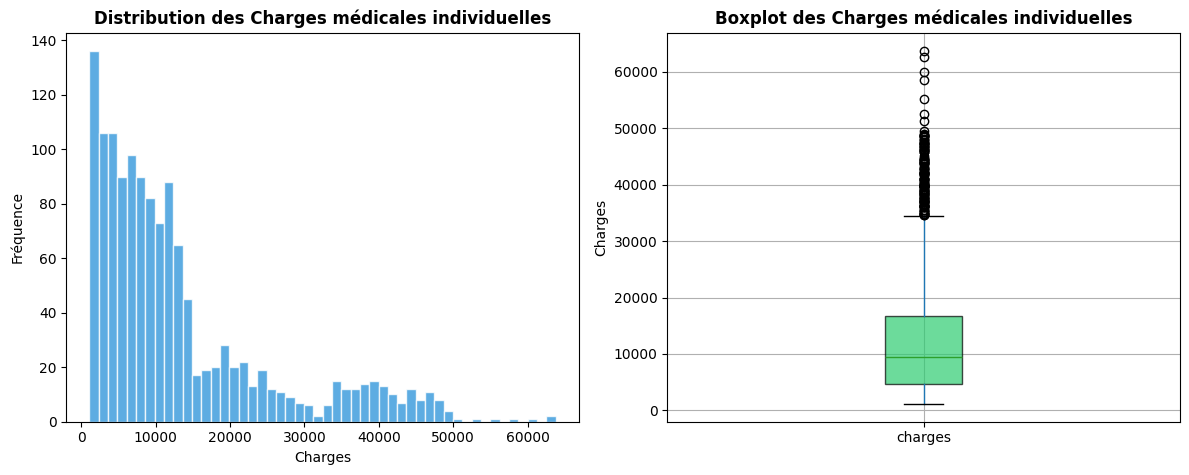

In [ ]:
# Distribution de la variable Charges :
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 🔹 Histogramme
axes[0].hist(df['charges'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title("Distribution des Charges médicales individuelles", fontweight='bold')
axes[0].set_xlabel("Charges")
axes[0].set_ylabel("Fréquence")

# 🔹 Boxplot
df.boxplot(column='charges', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.7))

axes[1].set_title("Boxplot des Charges médicales individuelles", fontweight='bold')
axes[1].set_ylabel("Charges")
axes[1].set_xlabel("")

# Enlever le titre automatique
plt.suptitle('')

plt.tight_layout()
plt.show()

**L'histogramme de distribution des charges médicales individuelles** montre que la majorité des charges médicales se concentre entre les valeurs 0 et 15000 .  <br>
**Le Boxplot de la variable charges** montre que la majorité des valeurs sont concentrées entre 0 et 15 000 (IQR). Les valeurs extrêmes s'étendent de 0 à 35 000. La distribution présente une asymétrie à droite, caractérisée par une queue étendue vers les grandes valeurs. Cela indique que la plupart des individus ont des charges faibles, et le boxplot présente plusieurs valeurs aberrantes situées dans la partie supérieure.

#### Comptage des modalités pour les variables catégorielles

/tmp/ipykernel_4243/3088090795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2')


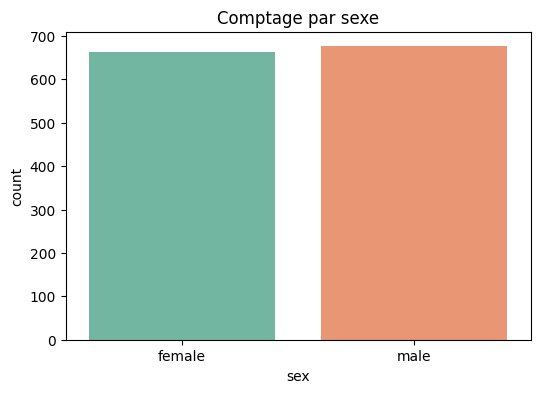

In [ ]:
#Les modalités pour la variable sex
plt.figure(figsize=(6,4))
sns.countplot(x='sex', data=df, palette='Set2')
plt.title("Comptage par sexe")
plt.show()

**Le Countplot de la variable sex** indique que le nombre d'individus male est légèrement plus grand que le nombre d'individus female .

/tmp/ipykernel_4243/1481631559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette='Set2')


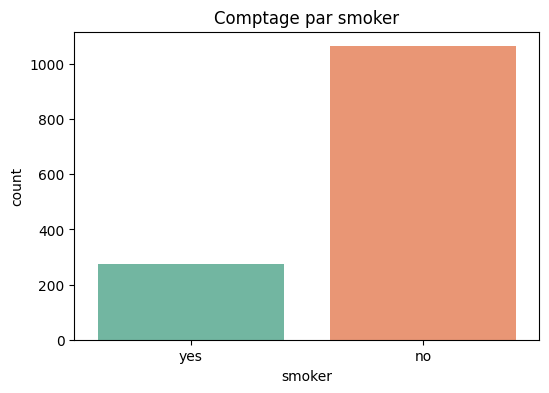

In [ ]:
#Les modalités pour la variable smoker
plt.figure(figsize=(6,4))
sns.countplot(x='smoker', data=df, palette='Set2')
plt.title("Comptage par smoker")
plt.show()

**Le Countplot de la variable smoker** indique que la majorité des individus sont non fumeurs avec l'existance de quelques individus qui sont des fumeurs .

/tmp/ipykernel_4243/3818019147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='Set2')


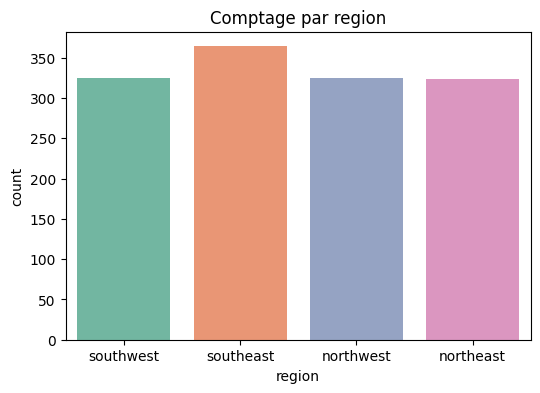

In [ ]:
#Les modalités pour la variable region
plt.figure(figsize=(6,4))
sns.countplot(x='region', data=df, palette='Set2')
plt.title("Comptage par region")
plt.show()

**Le Countplot de la variable region** indique Le nombre d'individus provenant des régions southwest, northwest et northeast est identique, alors que le nombre des individus d'origine southeast est plus grand .

### 4.2 Analyse Bivariée

#### Relation entre chaque feature et la variable charges : on va identifier l'influence de chaque feature sur les charges .

In [ ]:
print(df['age'].max(),df['bmi'].max(),df['children'].max())

64 53.13 5


la fonction **.max()** est appliquée pour savoir les valeurs maximales des variables numériques pour qu'on peut ensuite réaliser la division de ces features en des groupes et réaliser les Boxplots par catégorie .   

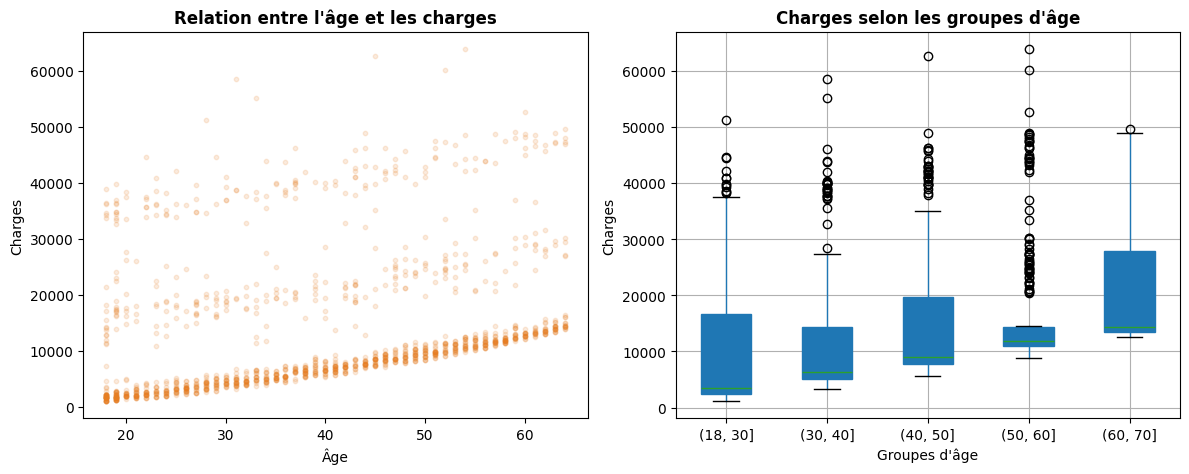

In [ ]:
# Relation entre age et charges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#  Scatter plot
axes[0].scatter(df['age'], df['charges'], alpha=0.15, s=10, c='#e67e22')
axes[0].set_title("Relation entre l'âge et les charges", fontweight='bold')
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Charges")

# Créer les groupes d'âge
df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,60,70])
# Boxplot par catégorie d'âge
df.boxplot(column='charges', by='age_group', ax=axes[1], patch_artist=True)

axes[1].set_title("Charges selon les groupes d'âge", fontweight='bold')
axes[1].set_xlabel("Groupes d'âge")
axes[1].set_ylabel("Charges")

plt.suptitle('')

plt.tight_layout()
plt.show()

**Scatter Plot** montre une relation positive et forte entre l'âge et les charges puisque les points présentent une tendance croissante et ils sont disposés sur une même direction dits alignés pour les valeurs faibles de charges. Les points deviennent dispersés pour des valeurs de charges supérieurs à 10500 montrant une relation faible .    
**Boxplot par catégorie d'âge** est réalisé en divisant l'ensemble des âges selon des groupes .  <br>
On observe sur les 4 catégories crées que plus l'âge augmente, plus les charges médicales augmentent. Aussi, la médiane des boxplots monte progressivement avec l'âge. Cette observation montre aussi la presence de Beaucoup de points au-dessus des box dites des valeurs aberantes et dans tous les groupes surtout pour les personnes agées de 40 à 70 ans, ce qui indique que certains patients ont des coûts très élevé . Les boxplots sont tirés vers le haut (longues moustaches supérieures et la médiane est proche du bas) , Cela signifie que la distribution est asymétrique à droite .<br>
**Conclusion** : L'âge a un impact fort sur les charges .
Les charges augmentent avec l'âge ,
deviennent plus dispersées et
contiennent plus de cas extrêmes .

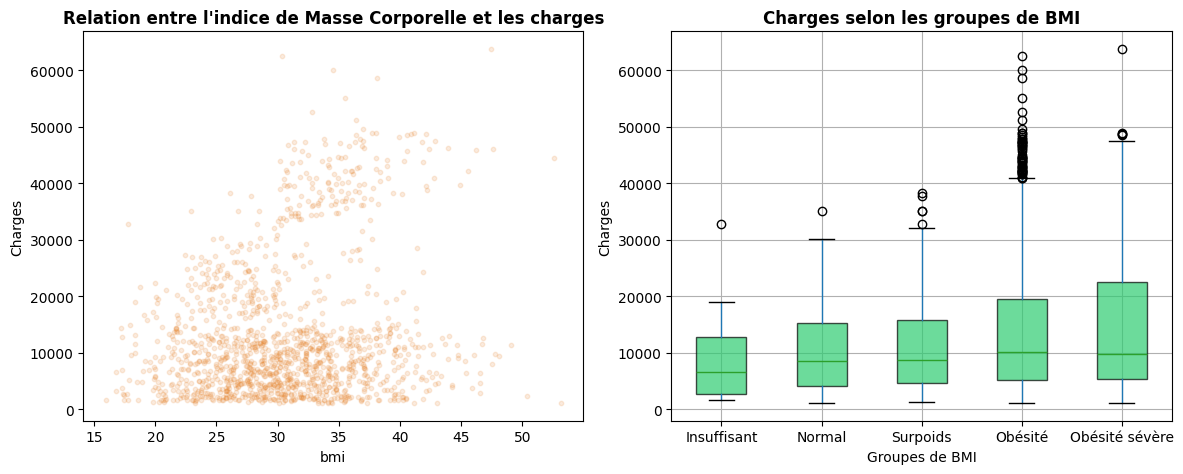

In [ ]:
# Relation entre bmi et charges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#  Scatter plot
axes[0].scatter(df['bmi'], df['charges'], alpha=0.15, s=10, c='#e67e22')
axes[0].set_title("Relation entre l'indice de Masse Corporelle et les charges", fontweight='bold')
axes[0].set_xlabel("bmi")
axes[0].set_ylabel("Charges")

#Créer les groupes de BMI
df['bmi_group'] = pd.cut(df['bmi'],
                         bins=[10, 18.5, 25, 30, 40, 55],
                         labels=['Insuffisant', 'Normal', 'Surpoids', 'Obésité', 'Obésité sévère'])

# Boxplot par catégorie de BMI
df.boxplot(column='charges', by='bmi_group', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#2ecc71', alpha=0.7))

axes[1].set_title("Charges selon les groupes de BMI", fontweight='bold')
axes[1].set_xlabel("Groupes de BMI")
axes[1].set_ylabel("Charges")

# Supprimer le titre automatique
plt.suptitle('')

plt.tight_layout()
plt.show()

**Scatter Plot** montre une tendance globale croissante, indiquant une relation positive entre le BMI et les charges. En effet, lorsque le BMI augmente, les charges médicales ont tendance à augmenter également.
Les points sont relativement proches les uns des autres, ce qui suggère une relation modérément forte entre les deux variables. <br>
Cependant, pour les valeurs de charges supérieures à 40 000, les points deviennent plus dispersés, ce qui indique une variabilité plus élevée et une relation moins forte dans cette zone. Cela peut s'expliquer par la présence de valeurs aberrantes. <br>
**Boxplot par catégorie de BMI** est réalisé en divisant les valeurs de BMI en plusieurs groupes.

On observe que plus l'indice de BMI augmente, plus les charges médicales ont tendance à augmenter. Les médianes et les intervalles interquartiles (IQR) des catégories « normal » et « surpoids » sont relativement similaires. En revanche, pour les catégories « obésité » et « obésité sévère », la médiane est approximativement égale à 10 000, avec un IQR plus large, indiquant une plus grande dispersion des charges dans ces groupes.

On remarque également la présence de nombreuses valeurs aberrantes, correspondant à des charges très élevées, notamment dans toutes les catégories, et plus particulièrement dans la catégorie « obésité ».

Enfin, les boxplots sont étirés vers le haut, ce qui indique une asymétrie à droite de la distribution <br>
**Conclusion:** le BMI influence positivement les charges médicales, mais la forte dispersion et les valeurs aberrantes montrent que d'autres facteurs interviennent.



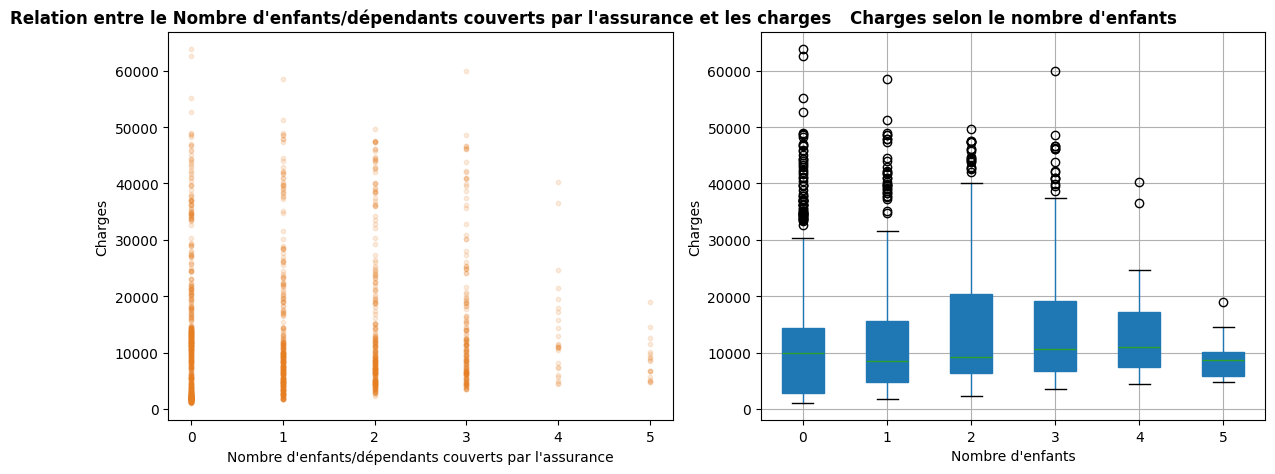

In [ ]:
# Relation entre children et charges
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#  Scatter plot
axes[0].scatter(df['children'], df['charges'], alpha=0.15, s=10, c='#e67e22')
axes[0].set_title("Relation entre le Nombre d'enfants/dépendants couverts par l'assurance et les charges", fontweight='bold')
axes[0].set_xlabel("Nombre d'enfants/dépendants couverts par l'assurance")
axes[0].set_ylabel("Charges")
# Boxplot
df.boxplot(column='charges', by='children', ax=axes[1], patch_artist=True)

axes[1].set_title("Charges selon le nombre d'enfants", fontweight='bold')
axes[1].set_xlabel("Nombre d'enfants")
axes[1].set_ylabel("Charges")

plt.suptitle('')

plt.tight_layout()
plt.show()

**Scatter plot** montre une tendance croissante entre le nombre d'enfants/dépendants couverts par l'assurance et les charges médicales. Pour un nombre d'enfants entre 0 et 3, les points sont proches, ce qui indique une relation plus stable dans cet intervalle. <br>
En revanche, pour un nombre d'enfants égal à 4 et 5, la tendance reste croissante, mais les points deviennent plus dispersés, ce qui traduit une variabilité plus élevée et une relation moins marquée dans cette zone. <br>
**Boxplot par nombre d'enfants** montre que les médianes des charges sont relativement proches pour les différentes catégories. Toutefois, une légère augmentation de la médiane peut être observée pour certains groupes, notamment entre 2 et 4 enfants. <br>
La dispersion des données (IQR) varie selon les catégories, avec une augmentation plus importante pour les groupes ayant entre 2 et 3 enfants.<br>
On remarque également la présence de nombreuses valeurs aberrantes dans presque toutes les catégories, en particulier pour les faibles nombres d'enfants (0 et 1), avec des charges très élevées dépassant parfois 60 000.<br>
Enfin, les distributions sont globalement asymétriques à droite (tirées vers le haut), ce qui indique que certaines personnes présentent des coûts médicaux exceptionnellement élevés, indépendamment du nombre d'enfants. <br>
**Conclusion:** l'analyse du scatter plot et du boxplot montre que le nombre d'enfants a un impact limité sur les charges médicales. Bien qu'une légère tendance croissante soit observée, notamment pour certains groupes, la relation reste globalement faible et moins marquée comparée à d'autres variables.
La forte dispersion des données ainsi que la présence de nombreuses valeurs aberrantes dans toutes les catégories indiquent que les charges médicales varient considérablement indépendamment du nombre d'enfants. De plus, l'asymétrie à droite des distributions met en évidence l'existence de coûts exceptionnellement élevés pour certains individus.  

<Figure size 600x500 with 0 Axes>

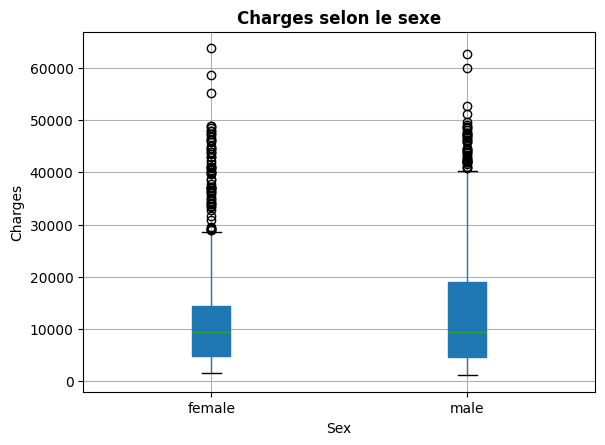

In [ ]:
#Relation entre sex et charges
#boxplot
plt.figure(figsize=(6,5))

df.boxplot(column='charges', by='sex', patch_artist=True)

plt.title("Charges selon le sexe", fontweight='bold')
plt.suptitle('')
plt.xlabel("Sex")
plt.ylabel("Charges")

plt.show()

**Boxplot** selon le sexe indique que l'intervalle interquartile (IQR) est plus large chez les hommes que chez les femmes, ce qui traduit une plus grande dispersion des charges médicales chez les individus de sexe masculin. La médiane est cependant similaire pour les deux catégories, ce qui suggère un niveau de charges central comparable entre les hommes et les femmes.

On observe également que les distributions sont étirées vers le haut, indiquant une asymétrie à droite, avec la présence de nombreuses valeurs aberrantes dans les deux groupes. <br>
**Conclusion:** le sexe ne semble pas avoir un impact significatif sur le niveau central des charges médicales, bien que les hommes présentent une variabilité légèrement plus élevée.

<Figure size 600x500 with 0 Axes>

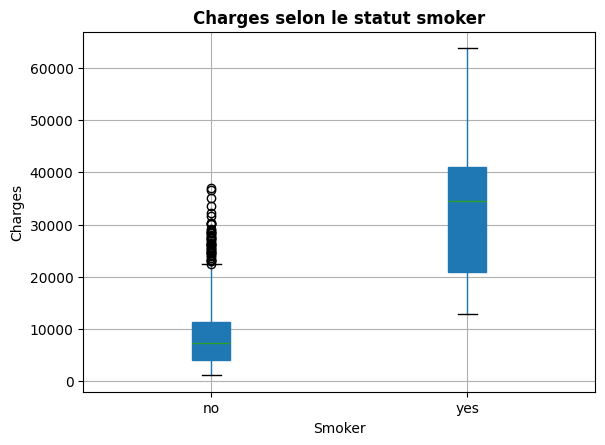

In [ ]:
#Relation entre smoker et charges
#boxplot
plt.figure(figsize=(6,5))

df.boxplot(column='charges', by='smoker', patch_artist=True)

plt.title("Charges selon le statut smoker", fontweight='bold')
plt.suptitle('')
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

**Boxplot** selon le statut smoker montre une différence nette entre les deux groupes.  <br> L'intervalle interquartile (IQR) est plus large chez les fumeurs que chez les non fumeurs, ce qui traduit une plus grande dispersion des charges médicales chez les individus fumeurs. Les charges médicales sont globalement beaucoup plus élevées chez les fumeurs, tandis que les non-fumeurs présentent des valeurs nettement plus faibles et plus concentrées. <br>
La médiane des individus fumeurs est significativement plus élevée et se situe bien au-dessus du boxplot que celle des individus non-fumeurs, ce qui confirme que le statut de fumeur est associé à une augmentation importante des coûts médicaux. <br>
On observe également que les distributions sont étirées vers le haut, indiquant une asymétrie à droite, avec la présence de nombreuses valeurs aberrantes chez les individus non fumeurs. <br>
**Conclusion:** le statut de fumeur a un impact significatif sur les charges médicales. Les fumeurs présentent des coûts plus élevés et une variabilité plus importante .

<Figure size 600x500 with 0 Axes>

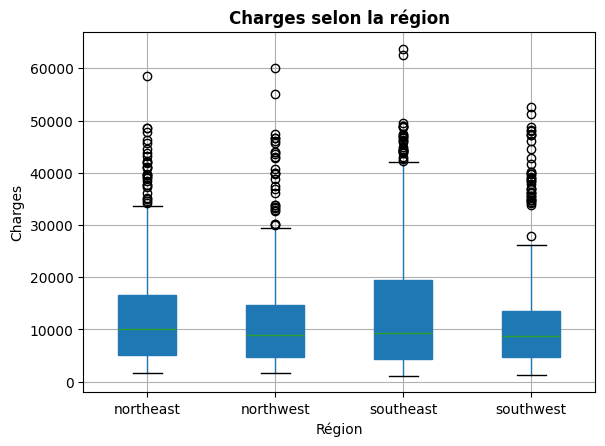

In [ ]:
#Relation entre region et charges
#boxplot
plt.figure(figsize=(6,5))

df.boxplot(column='charges', by='region', patch_artist=True)

plt.title("Charges selon la région", fontweight='bold')
plt.suptitle('')
plt.xlabel("Région")
plt.ylabel("Charges")

plt.show()

**Boxplot** selon la région indique que les régions northeast et southeast montrent des charges plus élevées et plus dispersées.
Les régions northwest et southwest semblent plus stables, avec des charges généralement plus faibles. <br>
La présence d'outliers dans toutes les régions suggère qu'il existe des cas particuliers ayant des charges trés élevées. <br>
**Conclusion:** Les charges varient fortement selon la région.

#### Analyse de l'impact du statut smoker sur les charges

In [ ]:
#Moyenne des charges par groupe
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8434.268298
yes,32050.231832


le code ci dessus compare les **valeurs moyennes**. <br>
on remarque que les individus fumeurs présentent une moyenne élevée alors que les individus non-fumeurs présentent une moyenne faible ce qui indique que le statut de fumeur est associé à une augmentation des charges médicales. <br>



<Figure size 600x500 with 0 Axes>

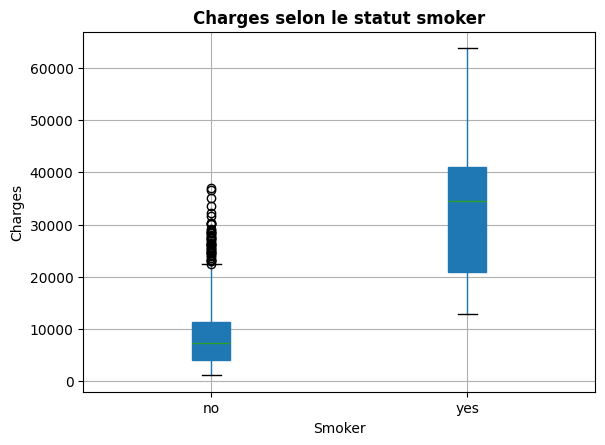

In [ ]:
#boxplot
plt.figure(figsize=(6,5))

df.boxplot(column='charges', by='smoker', patch_artist=True)

plt.title("Charges selon le statut smoker", fontweight='bold')
plt.suptitle('')
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

**Boxplot** selon le statut smoker montre une différence nette entre les deux groupes.  <br> L'intervalle interquartile (IQR) est plus large chez les fumeurs que chez les non fumeurs, ce qui traduit une plus grande dispersion des charges médicales chez les individus fumeurs. Les charges médicales sont globalement beaucoup plus élevées chez les fumeurs, tandis que les non-fumeurs présentent des valeurs nettement plus faibles et plus concentrées. <br>
La médiane des individus fumeurs est significativement plus élevée et se situe bien au-dessus du boxplot que celle des individus non-fumeurs, ce qui confirme que le statut de fumeur est associé à une augmentation importante des coûts médicaux. <br>
On observe également que les distributions sont étirées vers le haut, indiquant une asymétrie à droite, avec la présence de nombreuses valeurs aberrantes chez les individus non fumeurs. <br>

**Analyse de l'impact du statut smoker sur les charges :**
<br>
<h4> 1- Impact sur le niveau des charges : <br>
Les fumeurs ont des charges beaucoup plus élevées que les non-fumeurs.
confirmé par une moyenne élevée chez les fumeurs, médiane élevée et
boxplot globalement décalé vers le haut. Donc, le statut de fumeur est associé à une augmentation significative des coûts médicaux.
<h4> 2- Impact sur la variabilité : <br>
les fumeurs présentent une plus grande variabilité des charges
confirmé par un IQR plus large et une distribution plus étalée .
Donc, les charges médicales des fumeurs sont plus instables et plus hétérogènes.

**Conclusion:** L'analyse du boxplot et des valeurs moyennes montre clairement que le statut de fumeur a un impact significatif sur les charges médicales. Les fumeurs présentent des coûts moyens et médians plus élevés, ainsi qu’une plus grande dispersion des valeurs.

#### Analyse de l'interaction bmi × smoker sur les charges : on veut savoir l'effet du bmi sur les charges selon que la personne fume ou non .

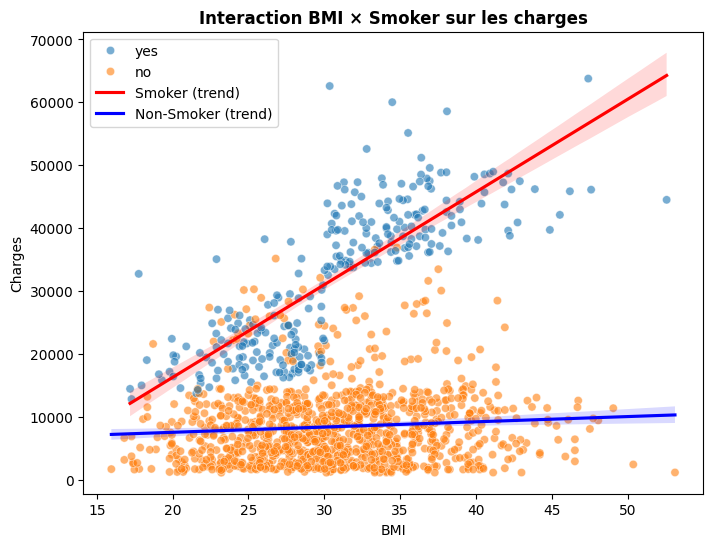

In [ ]:
plt.figure(figsize=(8,6))

# Scatter plot avec séparation smoker
sns.scatterplot(
    data=df,
    x='bmi',
    y='charges',
    hue='smoker',
    alpha=0.6
)

# Lignes de tendance
sns.regplot(
    data=df[df['smoker']=='yes'],
    x='bmi',
    y='charges',
    scatter=False,
    color='red',
    label='Smoker (trend)'
)

sns.regplot(
    data=df[df['smoker']=='no'],
    x='bmi',
    y='charges',
    scatter=False,
    color='blue',
    label='Non-Smoker (trend)'
)

plt.title("Interaction BMI × Smoker sur les charges", fontweight='bold')
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.legend()
plt.show()

**Analyse du Scatter plot de l'interaction** <br>
<h4> 1- Le graphique montre que les charges médicales augmentent avec le BMI pour les individus fumeurs alors que pour les individus non fumeurs les charges sont presque proches .
<h4> 2- Les positions des lignes : la ligne rouge est au dessus de la ligne bleue, donc les fumerus ont des charges plus élevées que les non-fumeurs.
<h4> 3- Tendance des lignes : la ligne rouge est croissante alors que la ligne bleue est presque constante avec un peu d'inclinaison, ce qui indique que le BMI augmente plus fortement les charges chez les fumeurs.
<h4> 4- Comparaison du parallélisme des lignes : les lignes ne sont pas parallèles ce qui implique une interaction forte . <br>

**Conclusion:** Existance d'une interaction entre le BMI et le statut de fumeur : l'augmentation des charges avec le BMI est beaucoup plus importante chez les fumeurs que chez les non-fumeurs.

### 4.3 Analyse Multivariée

#### Matrice de corrélation (heatmap) entre les variables numériques

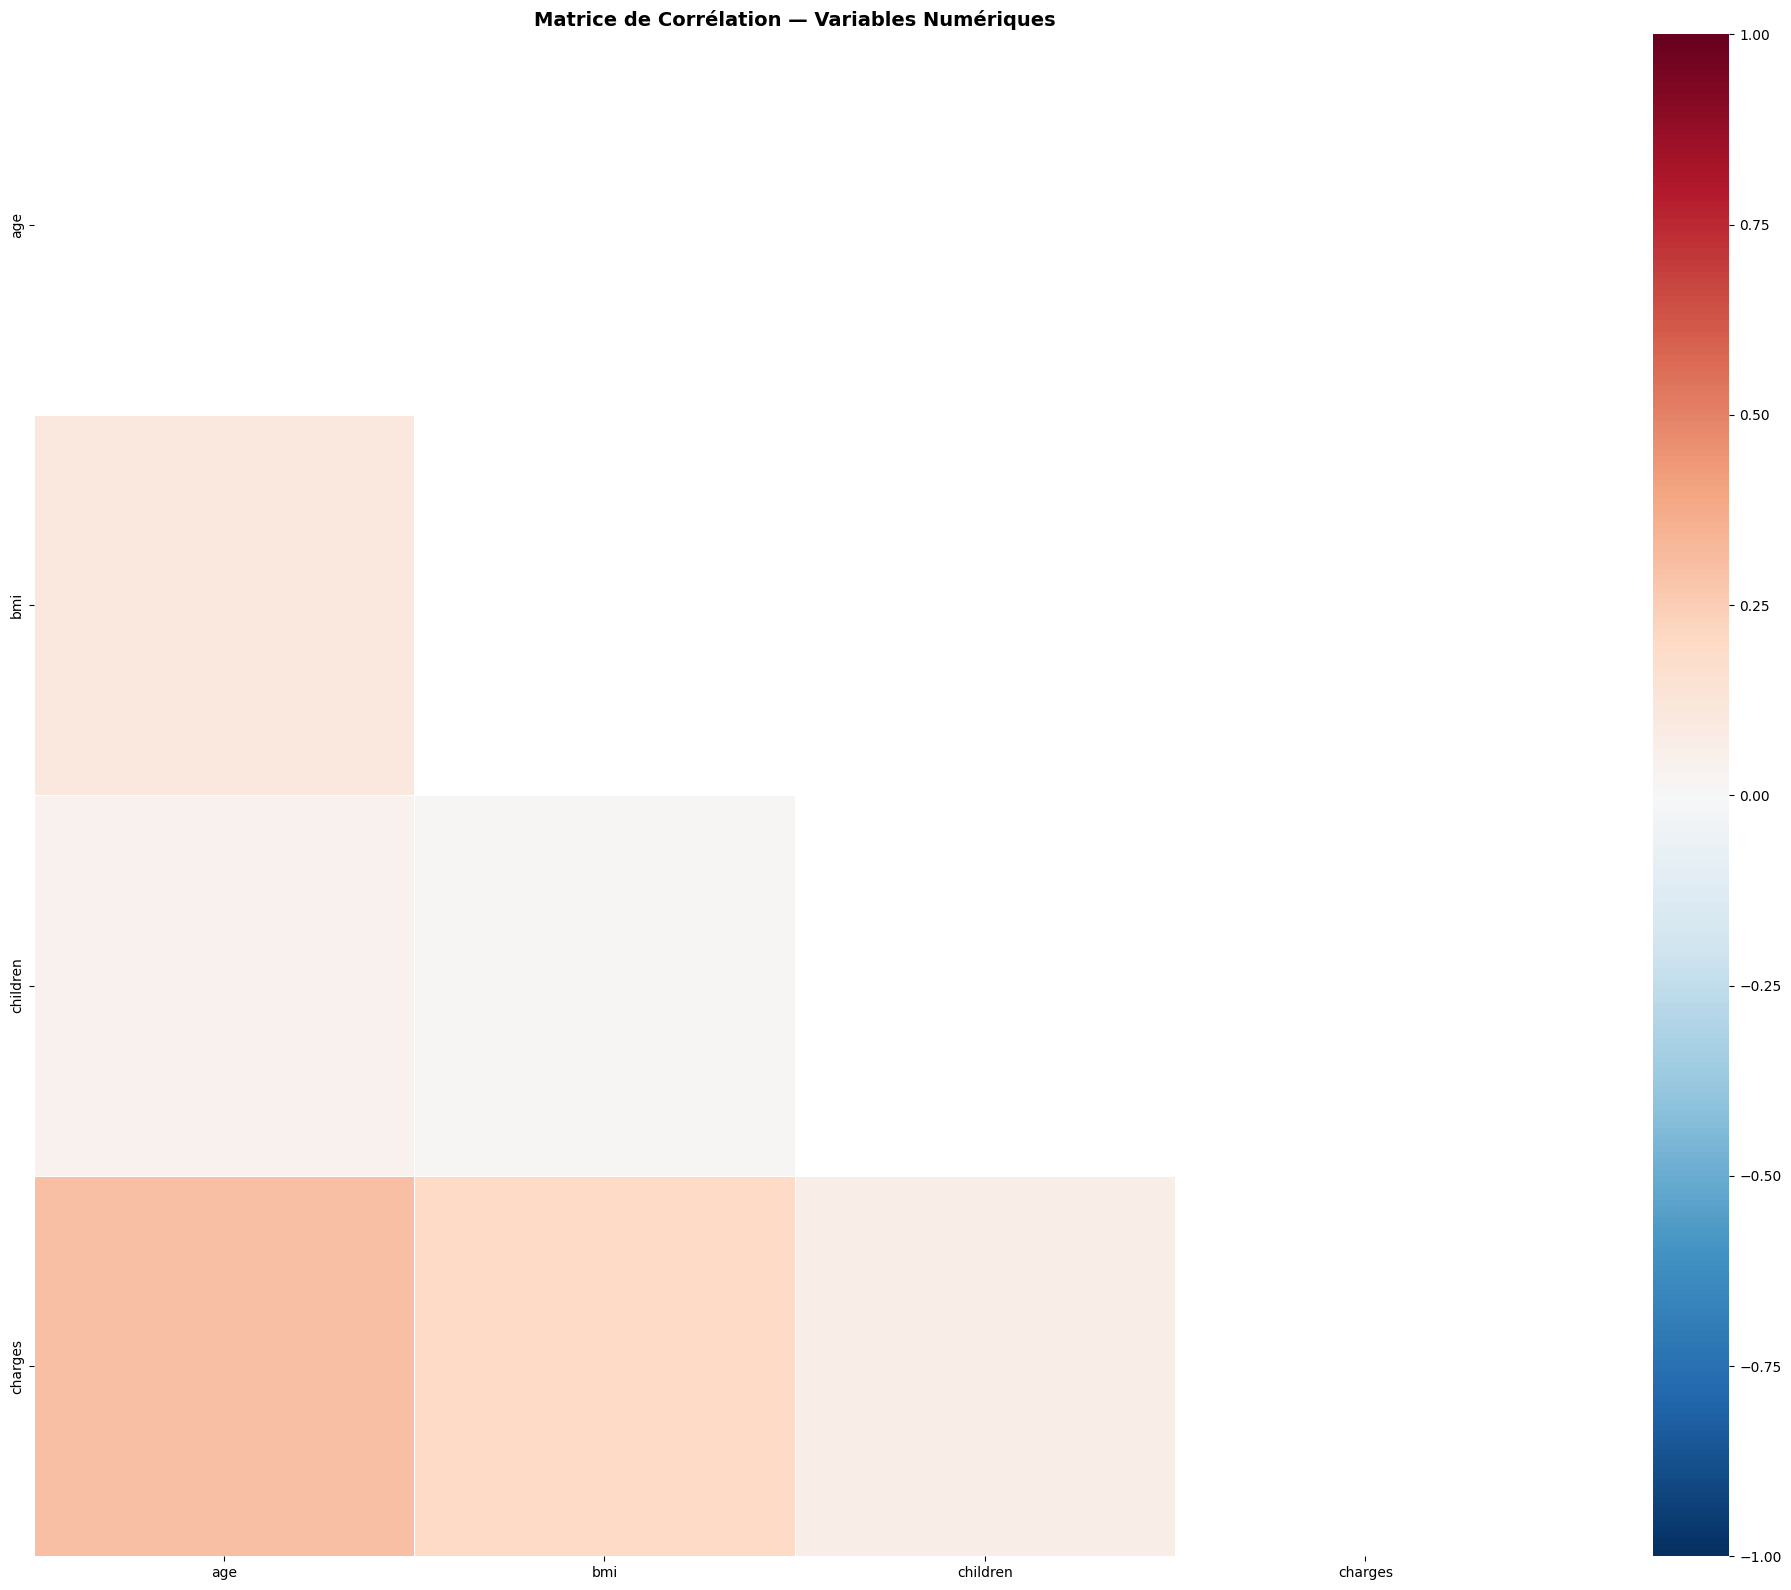

In [ ]:
# Matrice de corrélation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de Corrélation — Variables Numériques", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Définition d'une matrice de corrélation:** C'est un tableau qui montre la relation entre chaque paire de variables numériques.
les valeurs entre -1 et +1 et elle mesure une relation linéaire. <br>



In [ ]:
# Top corrélations avec les charges
price_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=False)

print("🔝 Variables les plus corrélées avec 'charges' :\n")

for i, (col, val) in enumerate(price_corr.items(), 1):
    direction = "+" if val > 0 else "-"
    print(f"{i:2d}. {col:<20s} {direction}{abs(val):.4f}")

🔝 Variables les plus corrélées avec 'charges' :

 1. age                  +0.2990
 2. bmi                  +0.1983
 3. children             +0.0680


**Analyse de la matrice de corrélation et des corrélations**  <br>
La corrélation entre l'âge et les charges est de 0.29, ce qui indique une corrélation positive faible à modérée. Cela signifie que les charges médicales ont tendance à augmenter légèrement avec l'âge, mais cette relation reste limitée.

La corrélation entre le BMI et les charges est de 0.19, ce qui traduit une corrélation positive faible. Ainsi, l'IMC influence les charges médicales, mais son impact est relativement faible .

En revanche, la corrélation entre le nombre d'enfants et les charges est de
0.06, ce qui correspond à une corrélation très faible voire négligeable. Cela suggère que le nombre d'enfants n'a pratiquement aucun effet sur les dépenses médicales.

#### Pairplot coloré par smoker

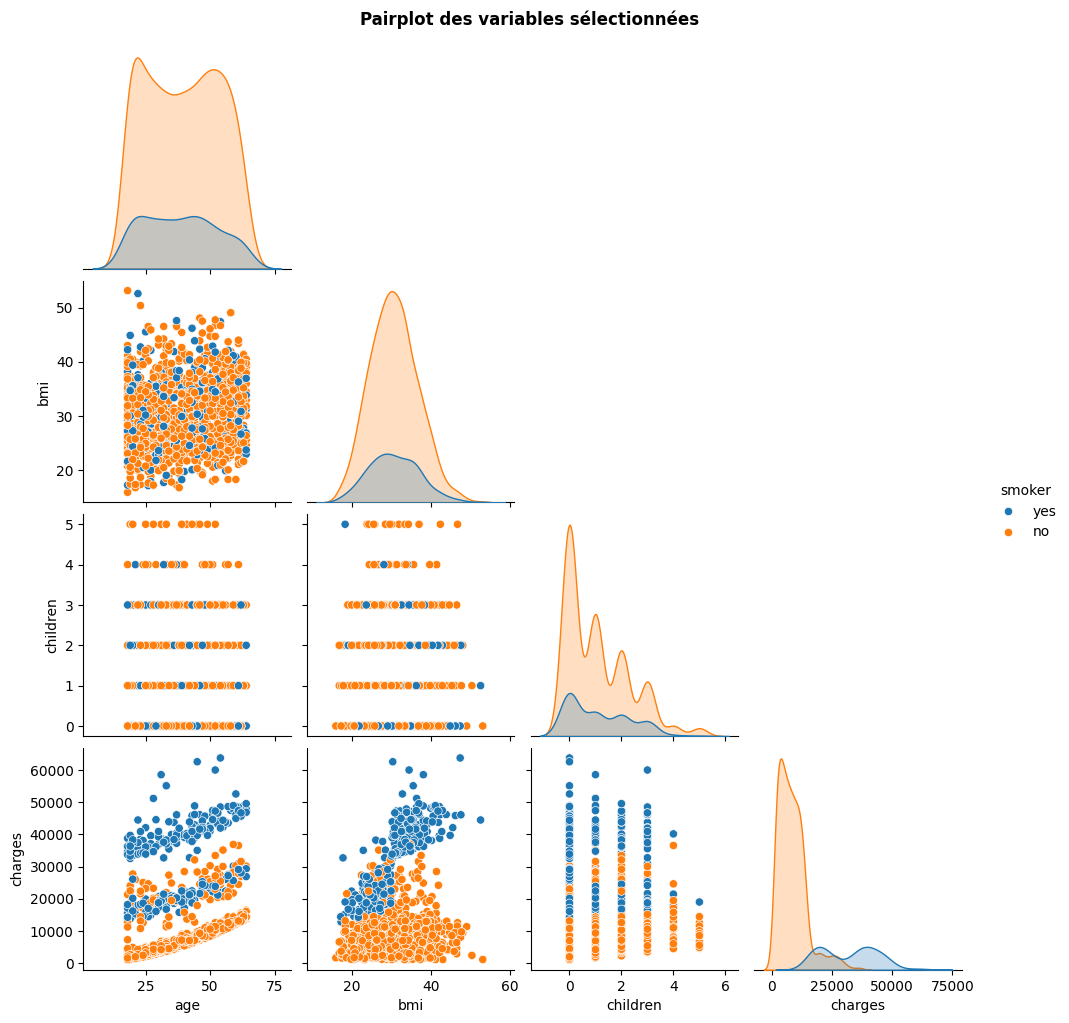

In [ ]:
#Pairplot
sns.pairplot(
    df,
    vars=['age', 'bmi', 'children' , 'charges'],  # variables numériques à afficher
    hue='smoker',
    diag_kind='kde',
    corner=True
)

plt.suptitle("Pairplot des variables sélectionnées", y=1.02, fontweight='bold')
plt.show()

**Définition du pairplot:** c'est un graphique qui permet de visualiser les relations entre toutes les variables numériques d'une base de données, ainsi que leur distribution, en les colorant éventuellement selon une variable catégorielle, dans notre cas c'est smoker. <br>
**Analyse du pairplot**
<h4> 1- Relation entre les deux variables charges et age selon la variable smoker : </h4>
Le nuage de points présente une tendance croissante pour les deux groupes d'individus (fumeurs et non-fumeurs) et plus l'age augmente plus les charges augmentent indiquant une relation positive. <br> On observe également que les points correspondant aux fumeurs sont globalement situés au-dessus de ceux des non-fumeurs, ce qui signifie que les fumeurs présentent des charges plus élevées.
<h4> 2- Relation entre les deux variables charges et bmi selon la variable smoker : </h4>
Le nuage de points présente une tendance croissante pour le groupe d'individus fumeurs et plus le bmi augmente plus les charges augmentent indiquant une relation positive . Pour le groupe d'individus non-fumeurs, le nuage de points presente une allure presque constante c'est à dire les charges n'augmentent pas avec l'augmentation du bmi. Par ailleurs, les fumeurs présentent des charges globalement plus élevées que les non-fumeurs, comme le montre la position supérieure de leurs points.
<h4> 3- Relation entre les deux variables charges et children selon la variable smoker : </h4>
Les points sont très dispersés verticalement pour chaque nombre d'enfants (0 à 5), les charges varient beaucoup, les fumeurs ont généralement des charges plus élevées que les non-fumeurs donc il n'existe pas de relation significative entre le nombre d'enfants et les charges médicales.
<h4> 4- la distribution de la variable charges selon la variable smoker : </h4>
Les fumeurs présentent une distribution étalée avec des valeurs très élevées
alors que les non-fumeurs présentent une distribution concentrée sur des valeurs plus faibles. Donc, les fumeurs présentent non seulement des charges plus élevées, mais aussi une plus grande variabilité. Les non-fumeurs ont des charges plus faibles et plus homogènes.
<h4> 5- Relation entre les deux variables children et age selon la variable smoker : </h4>
Le nuage de points montre que les valeurs de l'âge sont réparties sur tous les niveaux du nombre d'enfants (0 à 5), sans tendance claire. Les points sont dispersés, ce qui indique qu'il n'existe pas de relation significative entre l'âge et le nombre d'enfants. La distinction entre fumeurs et non-fumeurs n'apporte pas de différence notable dans cette relation.
<h4> 6- Relation entre les deux variables children et bmi selon la variable smoker : </h4>
Le nuage de points montre également une forte dispersion des valeurs du BMI pour chaque nombre d'enfants, sans tendance apparente. Cela indique qu'il n'existe pas de relation significative entre le BMI et le nombre d'enfants. La variable smoker ne semble pas influencer cette relation.
<h4> 7- La distribution de la variable children selon la variable smoker : </h4>
La distribution de la variable children montre plusieurs pics dans les deux courbes et la majorité des valeurs autour de 0, 1, 2 et 3 enfants . Aussi la courbe des non-fumeurs est plus haute que les fumeurs, indiquant que le groupe des individus non-fumeurs est plus nombreux .
<h4> 8- Relation entre les deux variables bmi et age selon la variable smoker : </h4>    
Le nuage de point montre que les points sont superposés avec un mélange des deux groupes (fumeurs et non-fumeurs) ce qui indique qu'il n'existe pas de relation significative entre les variables, ni de différence entre les fumeurs et les non-fumeurs.
<h4> 9- La distribution de la variable bmi selon la variable smoker : </h4>
La distribution de la variable BMI montre une densité légèrement plus élevée chez les non-fumeurs, indiquant une concentration plus importante de cette population dans certaines plages de BMI.
<h4> 10- La distribution de la variable age selon la variable smoker : </h4>
Les distributions de l'âge sont similaires pour les deux groupes, avec un étalement comparable, indiquant une variabilité proche des âges chez les fumeurs et les non-fumeurs .


### 4.4  Détection des outliers

#### Méthode IQR (Interquartile Range) sur les variables numériques

In [ ]:
# Détection des outliers avec IQR pour les variables numériques
cols = ['age', 'bmi', 'children', 'charges']

outliers_dict = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outliers_dict[col] = outliers

    print(f"\n{col}")
    print(f"Q1 = {Q1:.2f}")
    print(f"Q3 = {Q3:.2f}")
    print(f"IQR = {IQR:.2f}")
    print(f"Lower bound = {lower:.2f}")
    print(f"Upper bound = {upper:.2f}")
    print(f"Number of outliers = {outliers}")


age
Q1 = 27.00
Q3 = 51.00
IQR = 24.00
Lower bound = -9.00
Upper bound = 87.00
Number of outliers = 0

bmi
Q1 = 26.30
Q3 = 34.69
IQR = 8.40
Lower bound = 13.70
Upper bound = 47.29
Number of outliers = 9

children
Q1 = 0.00
Q3 = 2.00
IQR = 2.00
Lower bound = -3.00
Upper bound = 5.00
Number of outliers = 0

charges
Q1 = 4740.29
Q3 = 16639.91
IQR = 11899.63
Lower bound = -13109.15
Upper bound = 34489.35
Number of outliers = 139


les deux variables age et children n'ont pas de valeurs aberantes, alors que la variable bmi posséde 9 valeurs aberantes et charges posséde 139 valeurs aberantes.

#### Visualisation via boxplots

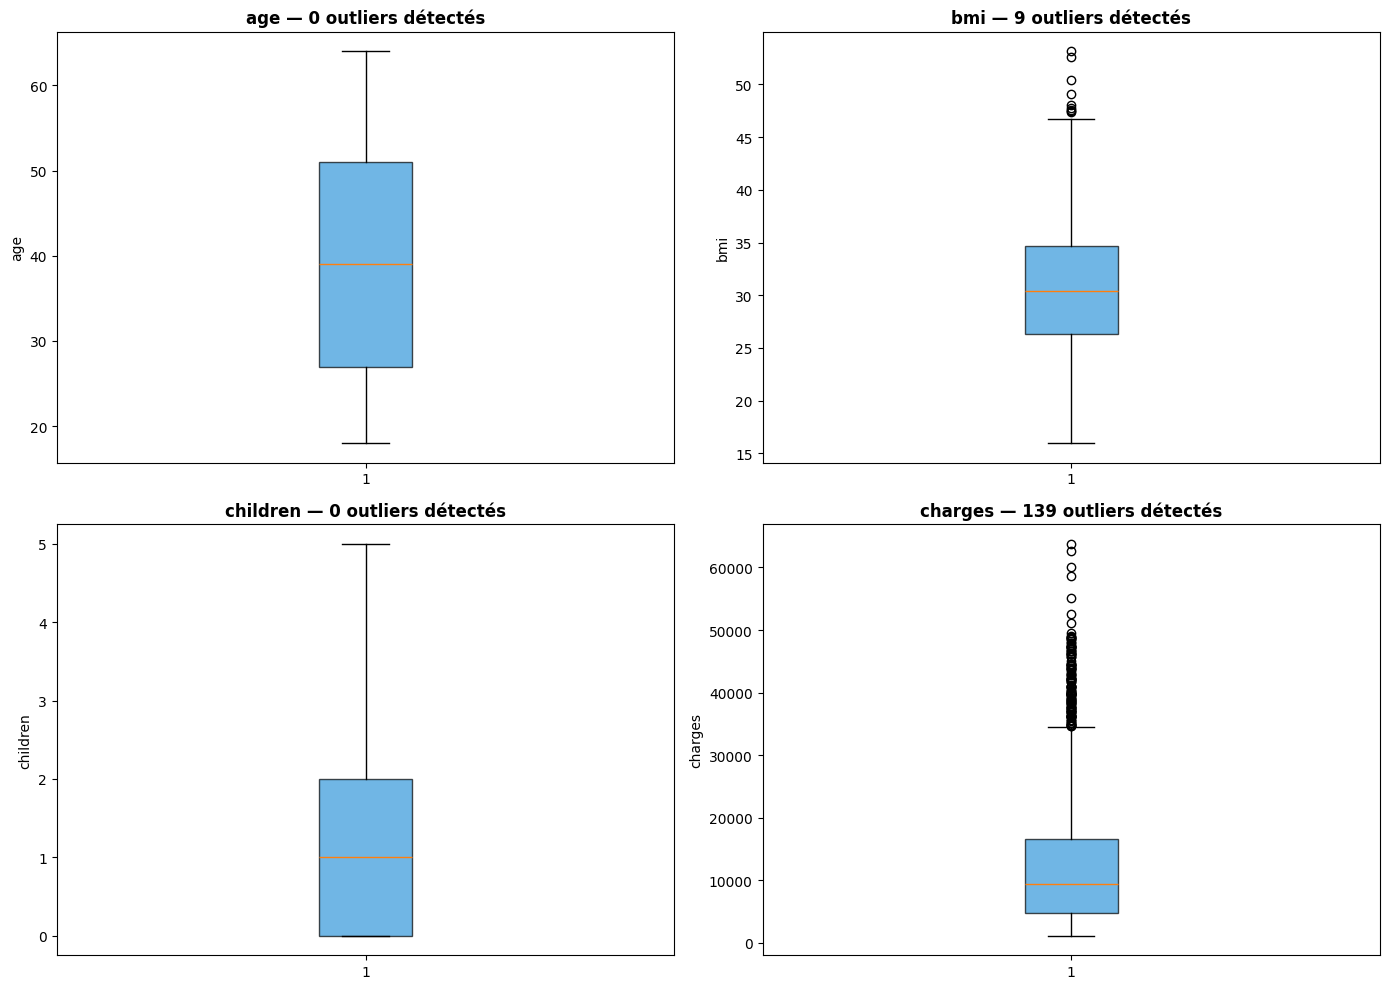

In [ ]:
#Boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

cols = ['age', 'bmi', 'children', 'charges']

for i, col in enumerate(cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7))

    axes[i].set_title(f'{col} — {outliers_dict[col]} outliers détectés', fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

La visualisation des boxplots confirme l'existance d'outliers dans les variables numériques bmi et charges et l'absence d'outliers dans les variables numériques age et children .

## 5. Nettoyage et Prétraitement

### 5.1 Valeurs Manquantes

#### Gestion des valeurs manquantes

In [ ]:
# Vérification des valeurs manquantes
missing_values = df.isnull().sum()

print("Nombre de valeurs manquantes par colonne :\n")
print(missing_values)

Nombre de valeurs manquantes par colonne :

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### 5.2 Gestion des valeurs doublons

In [ ]:
# Détection des doublons
duplicates = df.duplicated().sum()

print(f"Nombre de lignes dupliquées : {duplicates}")
# Afficher les lignes dupliquées
df_duplicates = df[df.duplicated()]

print(df_duplicates)

Nombre de lignes dupliquées : 1
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631


#### Suppression des doublons

In [ ]:
# Suppression des doublons
df_cleaned = df.drop_duplicates()

print("Doublons supprimés. Nouvelle taille :", df_cleaned.shape)

Doublons supprimés. Nouvelle taille : (1337, 7)


In [ ]:
#Vérifier après suppression
print("Nouvelle taille :", df_cleaned.shape)
print("Doublons restants :", df_cleaned.duplicated().sum())

Nouvelle taille : (1337, 7)
Doublons restants : 0


### 5.3 Encodage des variables catégorielles

In [ ]:
# Encodage des variables catégorielles avec One-Hot Encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)

print("✅ Shape après encodage :", df_cleaned.shape)
print("Colonnes :", df_cleaned.columns.tolist())

✅ Shape après encodage : (1337, 9)
Colonnes : ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


<h4>Justification du choix d'encodage</h4>

Ces variables sont <b>catégorielles nominales</b>, c'est-à-dire qu'elles ne possèdent aucun ordre logique. <br>

Donc, le <b>One-Hot Encoding</b> a été choisi car il transforme chaque catégorie en une variable binaire (0/1) et n'introduit aucune relation d'ordre. <br>

En revanche, le <b>Label Encoding</b> introduit une relation d'ordre artificielle, ce qui peut fausser l'apprentissage du modèle.

### 5.4 Feature Scaling appliqué aux variables numériques

In [ ]:
# Transformation log pour réduire l'effet des outliers pour la variables charges
df_cleaned['charges_log'] = np.log1p(df_cleaned['charges'])

<h4> Explication </h4>
L'analyse des données a montré la présence d'un nombre important de valeurs aberrantes, notamment dans la variable charges.
Pour atténuer l'effet de ces outliers, <b>une transformation logarithmique (log1p) </b> a été appliquée, permettant de
réduire l'asymétrie de la distribution,
stabiliser la variance afin d'améliorer les performances des modèles

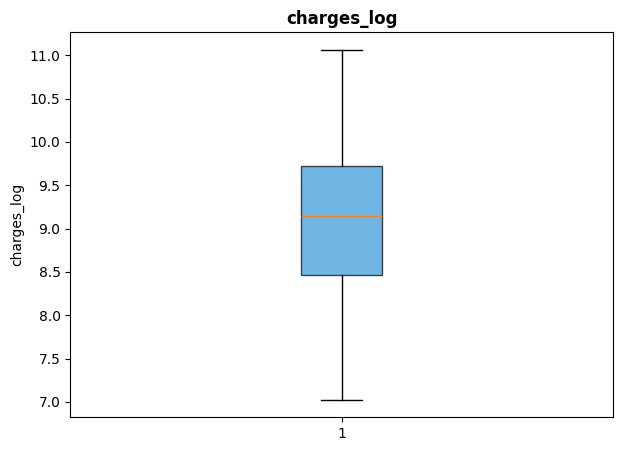

In [ ]:
# Boxplot uniquement charges_log
plt.figure(figsize=(7,5))

plt.boxplot(df_cleaned['charges_log'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7))

plt.title('charges_log', fontweight='bold')
plt.ylabel('charges_log')

plt.show()

In [ ]:
# Standardisation des variables numériques

num_cols = ['age', 'bmi', 'children', 'charges_log']

scaler = StandardScaler()
df_cleaned[num_cols] = scaler.fit_transform(df_cleaned[num_cols])
# Résultat final
print("✅ Shape final :", df_cleaned.shape)
print("Colonnes :", df_cleaned.columns.tolist())

✅ Shape final : (1337, 10)
Colonnes : ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest', 'charges_log']


<h4> Justification du choix de prétraitement </h4>
<b>La standardisation (StandardScaler)</b> a été utilisée pour normaliser les variables numériques, Ce choix est justifié par la présence d'outliers dans les données donc la standardisation est plus robuste dans ce cas par rapport à MinMaxScaler, vu que ce dernier est sensible aux valeurs extrêmes alors que StandardScaler permet de centrer les données autour de la moyenne avec un écart-type unitaire.

### 5.5 Train/Test Split

#### Définition des features et du target

In [ ]:
# Target (variable à prédire en log)
y = np.log1p(df_cleaned['charges'])

# Features
X = df_cleaned.drop(columns=['charges', 'charges_log'])

#### Séparation des données

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test / 80% train
    random_state=42     # reproductibilité des résultats pour garantit que le split est toujours le même
)

## 6. Modélisation

### 6.1 Linear Regression


#### Entrainement du modèle

In [ ]:
# Création du modèle
model = LinearRegression()

# Entraînement (OLS - Ordinary Least Squares)
model.fit(X_train, y_train)

LinearRegression()

#### Les prédictions

In [ ]:
# Prédictions en log
y_pred_log = model.predict(X_test)

In [ ]:
#Affichage des prédictions en log
print(y_pred_log[:10])

[ 8.93729181  8.67016676  9.51818498 10.27272176  8.60393505  9.204177
 10.05206352  8.01858825  8.95328049  9.27225545]


In [ ]:
#Affichage des prédictions sans log
y_pred_regression = np.expm1(y_pred_log)
print(y_pred_regression[:10])

[ 7609.5582764   5825.47088336 13603.8956562  28931.52747027
  5452.07557905  9937.55581369 23202.61868274  3035.88698368
  7732.21902657 10637.71993539]


#### Affichage et interprétation des coefficients du modèle




In [ ]:
# Récupérer les coefficients
coefficients = model.coef_

# Associer chaque coefficient à sa variable
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Trier pour mieux analyser
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

            Feature  Coefficient
4        smoker_yes     1.537330
0               age     0.477183
2          children     0.119475
1               bmi     0.080185
5  region_northwest    -0.043649
3          sex_male    -0.076769
7  region_southwest    -0.101224
6  region_southeast    -0.128562


<h4> Interprétation des coefficients du modèle </h4>
les coefficients = variation en % des charges puisqu'on travaille avec le log(charges). <br>
1. smoker_yes = 1.537 ≈ 153% : Les fumeurs paient environ 153% de charges en plus que les non-fumeurs. <br>
2. age = 0.477 ≈ 47.7% : Si l'âge augmente de 1 unité les charges augmentent d'environ 47% . <br>
3. children = 0.119 ≈ 11.9% : Chaque enfant supplémentaire augmente les charges d'environ 12% . <br>
4. bmi = 0.080 ≈ 8% : Une augmentation de BMI augmente les charges d'environ 8% . <br>
5. sex_male = -0.076 ≈ -7.6% : Les hommes paient environ 7.6% de moins que les femmes . <br>
6. regions, exemple: region_southeast = -0.128 ≈ -12.8% : Les personnes dans cette région paient environ 12% de moins que la région de référence . <br>
<b> conclusion : </b> Les résultats montrent que la variable smoker a l'impact le plus important sur les charges médicales. Les variables age, bmi et children ont également un effet positif, tandis que certaines régions et le sexe ont un impact négatif.


#### Cross_validation

In [ ]:
# Modèle
model = LinearRegression()

# Cross-validation (sur le train uniquement)
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Scores R² pour chaque fold:", scores)
print("Moyenne R² :", scores.mean())
print("Écart-type :", scores.std())

Scores R² pour chaque fold: [0.79837063 0.686754   0.83079379 0.76843592 0.73448575]
Moyenne R² : 0.7637680165722508
Écart-type : 0.050000386265051634


<h4>Evaluation de la robustesse du modèle </h4>
Les résultats de la validation croisée montrent un coefficient de détermination moyen de 0.764 avec un faible écart-type de 0.05. Cela indique que le modèle présente une bonne capacité de généralisation ainsi qu'une stabilité satisfaisante sur différents sous-ensembles de données, confirmant ainsi sa robustesse.

### 6.2 Ridge Regression

#### Entrainement du modèle

In [ ]:
# Création du modèle Ridge (L2 regularization)
ridge_model = Ridge(alpha=100)

# Entraînement du modèle
ridge_model.fit(X_train, y_train)

Ridge(alpha=100)

#### Les prédictions

In [ ]:
# Prédictions en log
y_pred_log_Ridge = ridge_model.predict(X_test)
print("Predictions log :")
print(y_pred_log_Ridge[:10])

Predictions log :
[9.02492982 8.80487663 9.53163373 9.8295546  8.79493147 9.33801811
 9.55944569 8.19109983 9.06613454 9.36020466]


In [ ]:
# Conversion en valeurs réelles
y_pred_Ridge = np.expm1(y_pred_log_Ridge)

print("Predictions réelles :")
print(y_pred_Ridge[:10])

Predictions réelles :
[ 8306.63143654  6665.67577359 13788.10029463 18573.67919688
  6599.70319615 11360.86790216 14176.98507254  3607.68900187
  8656.09538603 11615.76576667]


#### Affichage et interprétation des coefficients du modèle




In [ ]:
# Coefficients Ridge
coefficients_Ridge = ridge_model.coef_

# DataFrame
coef_df_Ridge = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients_Ridge
})

# Tri
coef_df_Ridge = coef_df_Ridge.sort_values(by='Coefficient', ascending=False)

print(coef_df_Ridge)

            Feature  Coefficient
4        smoker_yes     0.961287
0               age     0.430863
2          children     0.116038
1               bmi     0.064713
5  region_northwest    -0.019116
3          sex_male    -0.028390
6  region_southeast    -0.038612
7  region_southwest    -0.052524


<h4> Interprétation des coefficients du modèle </h4>
les coefficients = variation en % des charges puisqu'on travaille avec le log(charges). <br>
1. smoker_yes = 0.961 :Les fumeurs ont environ +96% de charges en plus que les non-fumeurs. <br>
2. age = 0.431: Une augmentation de l'âge (1 unité standardisée) entraîne une augmentation d'environ +43% des charges. <br>
3. children = 0.116: Avoir des enfants augmente les charges d'environ +12%. <br>
4. bmi = 0.065 : Une augmentation du BMI augmente les charges d'environ +6.5%.<br>
5. sex_male = -0.028 : Être un homme réduit légèrement les charges d'environ -2.8% par rapport aux femmes. <br>
6. regions, exemple: northwest : -1.9% : Les personnes dans cette région paient environ 1.9% de moins que la région de référence . <br>
<b> conclusion : </b> L'analyse des coefficients du modèle Ridge montre que la variable la plus influente sur les charges médicales est le statut de fumeur, avec une augmentation d'environ 96% des coûts. L'âge constitue également un facteur important, tandis que l'indice de masse corporelle et le nombre d'enfants ont un impact modéré. Les variables liées au sexe et à la région ont un effet marginal sur les charges.


#### Cross_validation

In [ ]:
ridge_model = Ridge(alpha=100)

scores_ridge = cross_val_score(
    ridge_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Scores R² pour chaque fold:", scores_ridge)
print("Moyenne R² :", scores_ridge.mean())
print("Écart-type :", scores_ridge.std())

Scores R² pour chaque fold: [0.71683685 0.66324983 0.73966835 0.71393816 0.6559735 ]
Moyenne R² : 0.6979333385121027
Écart-type : 0.03261558415936078


<h4> Evaluation de la robustesse du modèle </h4>
Les résultats de la validation croisée du modèle optimisé montrent un coefficient de détermination moyen de 0.698 avec un faible écart-type de 0.033. Cela indique que le modèle présente une capacité de généralisation correcte ainsi qu'une bonne stabilité sur différents sous-ensembles de données, confirmant ainsi sa robustesse.

#### Recherche des meilleurs hyperparamètres

In [ ]:
param_grid = {
    'alpha': np.logspace(-3, 3, 100)
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Meilleur alpha :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)

Meilleur alpha : {'alpha': np.float64(1.232846739442066)}
Meilleur score CV : 0.7463822064506969


### 6.3 Lasso Regression

#### Entrainement du modèle

In [ ]:
# Modèle Lasso
lasso_model = Lasso(alpha=0.1)

# Entraînement
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

#### Les prédictions

In [ ]:
# Prédictions en log
y_pred_log_lasso = lasso_model.predict(X_test)
print("Predictions log :")
print(y_pred_log_lasso[:10])

Predictions log :
[9.15458149 8.70546429 9.28140619 9.62717223 8.71182873 9.2027656
 9.38488602 8.41817618 9.01502792 9.22685765]


In [ ]:
# Conversion en valeurs réelles
y_pred_lasso = np.expm1(y_pred_log_lasso)

print("Predictions réelles :")
print(y_pred_lasso[:10])

Predictions réelles :
[ 9456.67150472  6034.80365503 10735.51890401 15170.47401622
  6073.34063851  9923.53841114 11906.05089742  4527.63651725
  8224.77601829 10165.54442282]


#### Affichage et interprétation des coefficients du modèle

In [ ]:
# Coefficients Lasso
coefficients_Lasso = lasso_model.coef_

# DataFrame
coef_df_Lasso = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients_Lasso
})

# Tri
coef_df_Lasso = coef_df_Lasso.sort_values(by='Coefficient', ascending=False)

print(coef_df_Lasso)

            Feature  Coefficient
4        smoker_yes     0.891251
0               age     0.382906
2          children     0.029034
1               bmi     0.000000
3          sex_male    -0.000000
5  region_northwest    -0.000000
6  region_southeast     0.000000
7  region_southwest    -0.000000


<h4> Interprétation des coefficients du modèle </h4>
les coefficients = variation en % des charges puisqu'on travaille avec le log(charges). <br>
1. smoker_yes =  0.891 :Les fumeurs ont environ +89% de charges en plus que les non-fumeurs. <br>
2. age = 0.382: Une augmentation de l'âge (1 unité standardisée) entraîne une augmentation d'environ +38% des charges. <br>
3. children = 0.029 : Avoir des enfants augmente les charges d'environ +3%. <br>
4. bmi = 0.000 : Le BMI n'a aucun impact significatif sur les charges dans ce modèle.<br>
5. sex_male = 0.000 : Le sexe n'influence pas les charges dans ce modèle. <br>
6. regions : 0.000 : La région n'a pas d'impact significatif sur les charges. <br>
<b> conclusion : </b> L'analyse des coefficients montre que le statut de fumeur est le facteur dominant influençant les charges médicales, avec une augmentation d'environ 89%. L'âge constitue également un facteur significatif. En revanche, les variables telles que l'indice de masse corporelle, le sexe et la région ont un impact négligeable, leurs coefficients étant proches de zéro, ce qui indique qu'elles n'apportent pas d'information significative au modèle dans ce contexte.


#### Cross_validation

In [ ]:
lasso_model = Lasso(alpha=0.1)

scores_lasso = cross_val_score(
    lasso_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Scores R² pour chaque fold:", scores_lasso)
print("Moyenne R² :", scores_lasso.mean())
print("Écart-type :", scores_lasso.std())

Scores R² pour chaque fold: [0.68135008 0.63076619 0.68248427 0.67075088 0.6204621 ]
Moyenne R² : 0.657162703509206
Écart-type : 0.026285205146433545


<h4> Evaluation de la robustesse du modèle </h4>
Les résultats de la validation croisée du modèle Lasso montrent un coefficient de détermination moyen de 0.657 avec un faible écart-type de 0.026. Cela indique que le modèle présente une capacité de généralisation modérée ainsi qu'une bonne stabilité sur différents sous-ensembles de données, confirmant ainsi sa robustesse

#### Recherche des meilleurs hyperparamètres

In [ ]:
# 1. Définir les valeurs de alpha à tester
alphas = np.logspace(-3, 1, 100)

# 2. Créer le modèle avec validation croisée
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)

# 3. Entraînement (CV automatique)
lasso_cv.fit(X_train, y_train)

# 4. Meilleur hyperparamètre
print("Meilleur alpha :", lasso_cv.alpha_)

# 5. Score du modèle
print("Score R² sur test :", lasso_cv.score(X_test, y_test))

Meilleur alpha : 0.001
Score R² sur test : 0.8283063727009831


### 6.4 ElasticNet Regression

#### Entrainement du modèle

In [ ]:
# Modèle ElasticNet
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Entraînement
elastic_model.fit(X_train, y_train)

ElasticNet(alpha=0.1)

#### Les prédictions

In [ ]:
# Prédictions en log
y_pred_log_ElasticNet = elastic_model.predict(X_test)
print("Predictions log :")
print(y_pred_log_ElasticNet[:10])

Predictions log :
[9.10288761 8.77720236 9.38655741 9.71719646 8.74879267 9.26984306
 9.42929102 8.32265705 9.02811101 9.30612222]


In [ ]:
# Conversion en valeurs réelles
y_pred_ElasticNet = np.expm1(y_pred_log_ElasticNet)

print("Predictions réelles :")
print(y_pred_ElasticNet[:10])

Predictions réelles :
[ 8980.18943532  6483.70990458 11925.96888238 16599.6388019
  6302.0736274  10612.08610543 12446.69848546  4115.08210788
  8333.10166812 11004.18953411]


#### Affichage et interprétation des coefficients du modèle

In [ ]:
# Coefficients ElasticNet
coefficients_ElasticNet = elastic_model.coef_

# DataFrame
coef_df_ElasticNet = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients_ElasticNet
})

# Tri
coef_df_ElasticNet = coef_df_ElasticNet.sort_values(by='Coefficient', ascending=False)

print(coef_df_ElasticNet)

            Feature  Coefficient
4        smoker_yes     0.918183
0               age     0.408378
2          children     0.074466
1               bmi     0.017639
3          sex_male    -0.000000
5  region_northwest    -0.000000
6  region_southeast    -0.000000
7  region_southwest    -0.000000


<h4> Interprétation des coefficients du modèle </h4>
les coefficients = variation en % des charges puisqu'on travaille avec le log(charges). <br>
1. smoker_yes =  0.918 :Les fumeurs paient environ +92% de charges en plus que les non-fumeurs. <br>
2. age = 0.408: Une augmentation de l'âge entraîne une augmentation d'environ +41% des charges. <br>
3. children = 0.074 : Avoir des enfants augmente les charges d'environ +7% .<br>
4. bmi = 0.018 : Une augmentation du BMI augmente légèrement les charges d'environ +1.8%..<br>
5. sex_male = 0.000 : Le sexe n'influence pas les charges dans ce modèle. <br>
6. regions : 0.000 : La région n'a pas d'impact significatif sur les charges. <br>
<b> conclusion : </b> L'analyse des coefficients du modèle ElasticNet montre que le statut de fumeur est le facteur le plus déterminant, suivi de l'âge. Le nombre d'enfants et l'indice de masse corporelle ont un impact plus faible. En revanche, les variables liées au sexe et à la région sont éliminées par le modèle, indiquant leur faible contribution à la prédiction des charges médicales. Cela illustre la capacité d'ElasticNet à combiner régularisation et sélection de variables.

#### Cross_validation

In [ ]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

scores_elastic = cross_val_score(
    elastic_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Scores R² pour chaque fold:", scores_elastic)
print("Moyenne R² :", scores_elastic.mean())
print("Écart-type :", scores_elastic.std())

Scores R² pour chaque fold: [0.70063701 0.64937588 0.70944843 0.69282173 0.63921319]
Moyenne R² : 0.6782992485553528
Écart-type : 0.028440922581042537


<h4> Evaluation de la robustesse du modèle </h4>
Les résultats de la validation croisée du modèle ElasticNet montrent un coefficient de détermination moyen de 0.678 avec un faible écart-type de 0.028. Cela indique que le modèle présente une bonne capacité de généralisation ainsi qu'une stabilité satisfaisante sur différents sous-ensembles de données, confirmant ainsi sa robustesse.

#### Recherche des meilleurs hyperparamètres

In [ ]:
# 1. Définir les valeurs à tester
alphas = np.logspace(-3, 1, 100)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# 2. Modèle ElasticNet avec CV
elastic_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000
)

# 3. Entraînement
elastic_cv.fit(X_train, y_train)

# 4. Meilleurs hyperparamètres
print("Meilleur alpha :", elastic_cv.alpha_)
print("Meilleur l1_ratio :", elastic_cv.l1_ratio_)

# 5. Score
print("Score R² test :", elastic_cv.score(X_test, y_test))

Meilleur alpha : 0.001
Meilleur l1_ratio : 0.1
Score R² test : 0.8289966864992384


#### Tableau comparatif des coefficients

In [ ]:
# OLS
model = LinearRegression()
model.fit(X_train, y_train)
coef_ols = model.coef_

# Ridge
ridge_model.fit(X_train, y_train)
coef_ridge = ridge_model.coef_

# Lasso
lasso_model.fit(X_train, y_train)
coef_lasso = lasso_model.coef_

# ElasticNet
elastic_model.fit(X_train, y_train)
coef_elastic = elastic_model.coef_

# Tableau comparatif
coef_comparison = pd.DataFrame({
    'Feature': X.columns,
    'OLS': coef_ols,
    'Ridge': coef_ridge,
    'Lasso': coef_lasso,
    'ElasticNet': coef_elastic
})

coef_comparison = coef_comparison.sort_values(by='OLS', ascending=False)

print(coef_comparison)

            Feature       OLS     Ridge     Lasso  ElasticNet
4        smoker_yes  1.537330  0.961287  0.891251    0.918183
0               age  0.477183  0.430863  0.382906    0.408378
2          children  0.119475  0.116038  0.029034    0.074466
1               bmi  0.080185  0.064713  0.000000    0.017639
5  region_northwest -0.043649 -0.019116 -0.000000   -0.000000
3          sex_male -0.076769 -0.028390 -0.000000   -0.000000
7  region_southwest -0.101224 -0.052524 -0.000000   -0.000000
6  region_southeast -0.128562 -0.038612  0.000000   -0.000000


## 7. Évaluation des Modèles

### 7.1 Métriques

In [ ]:
#Revenir à l’échelle réelle pour les valeurs de test
y_test_original = np.expm1(y_test)

In [ ]:
#calcul de toutes les métriques d’évaluation
def compute_metrics(y_true, y_pred, X_test):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    n = X_test.shape[0]
    p = X_test.shape[1]

    # sécurité division
    if n - p - 1 == 0:
        adj_r2 = np.nan
    else:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # MAPE sécurisé (évite division par 0)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100

    return mae, rmse, r2, adj_r2, mape

In [ ]:
results = []
#Stockage des prédictions dans un dictionnaire
models_preds = {
    "Linear Regression": y_pred_regression,
    "Ridge": y_pred_Ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_ElasticNet
}
# récupèrer les prédictions, calculer les métriques et ajouter au tableau results
for name, y_pred in models_preds.items():
    mae, rmse, r2, adj_r2, mape = compute_metrics(y_test_original, y_pred, X_test)

    results.append([name, mae, rmse, r2, adj_r2, mape])

### 7.2 Analyse des Résidus

In [ ]:
#Calcul des résidus : la différence entre la valeur réelle et la valeur prédite
residuals_linear = y_test_original - y_pred_regression
residuals_ridge = y_test_original - y_pred_Ridge
residuals_lasso = y_test_original - y_pred_lasso
residuals_elastic = y_test_original - y_pred_ElasticNet

#### Distribution des résidus

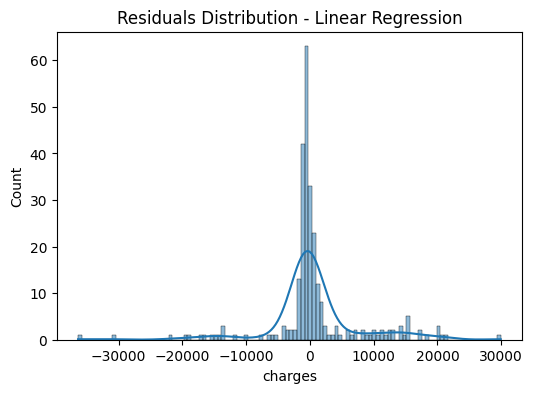

In [ ]:
#Linear Regression
plt.figure(figsize=(6,4))
sns.histplot(residuals_linear, kde=True)
plt.title("Residuals Distribution - Linear Regression")
plt.show()

<h4> Interprétation des résultats </h4>
Le modèle de régression linéaire montre que la majorité des résidus sont centrés autour de zéro et que la courbe en cloche superposée suggère une distribution proche de la normale et les erreurs ne présentent pas de biais systématique et qu'elles suivent une distribution normale ce qui confirme la validité du modèle

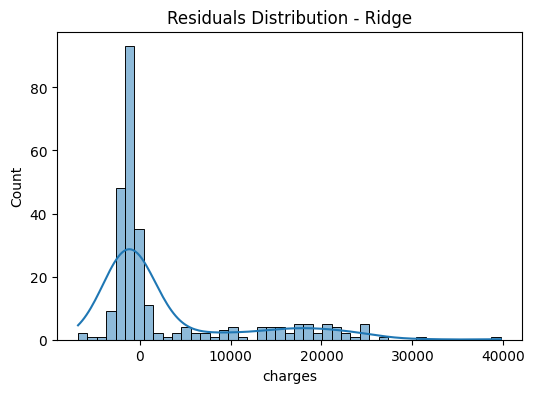

In [ ]:
# Ridge
plt.figure(figsize=(6,4))
sns.histplot(residuals_ridge, kde=True)
plt.title("Residuals Distribution - Ridge")
plt.show()

<h4> Interprétation des résultats </h4>
Le modèle de régression Ridge présente une bonne approximation pour la majorité des données avec des résidus majoritairement centrés autour de zéro, ce qui montre qu'il explique correctement la tendance des données. Toutefois, la distribution asymétrique et la longue queue positive révèlent qu'il reste sensible aux valeurs extrêmes.

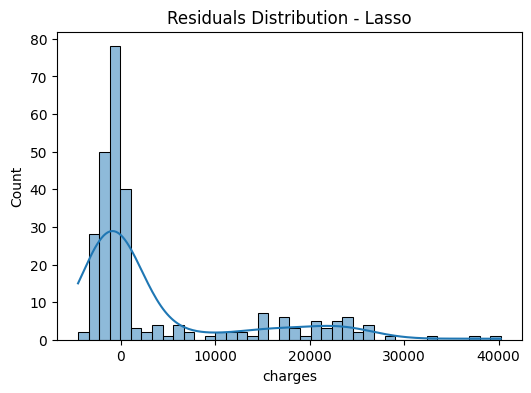

In [ ]:
# Lasso
plt.figure(figsize=(6,4))
sns.histplot(residuals_lasso, kde=True)
plt.title("Residuals Distribution - Lasso")
plt.show()

<h4> Interprétation des résultats </h4>
Le modèle de régression Lasso présente une bonne approximation pour la majorité des données avec des résidus majoritairement centrés autour de zéro, ce qui montre qu'il explique correctement la tendance des données. Toutefois, la distribution asymétrique et la longue queue positive révèlent qu'il reste sensible aux valeurs extrêmes.

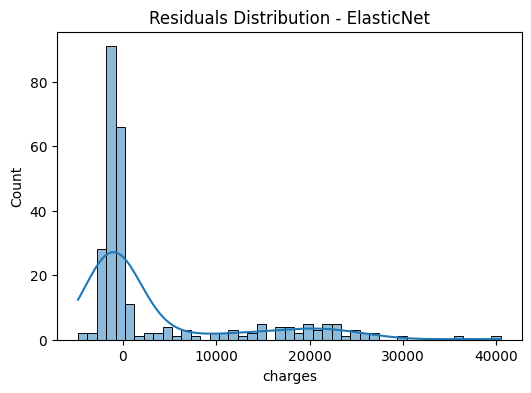

In [ ]:
# ElasticNet
plt.figure(figsize=(6,4))
sns.histplot(residuals_elastic, kde=True)
plt.title("Residuals Distribution - ElasticNet")
plt.show()

<h4> Interprétation des résultats </h4>
Le modèle de régression ElasticNet présente une bonne approximation pour la majorité des données avec des résidus majoritairement centrés autour de zéro, ce qui montre qu'il explique correctement la tendance des données. Toutefois, la distribution asymétrique et la longue queue positive révèlent qu'il reste sensible aux valeurs extrêmes.

#### Scatter plot Résidus vs Prédictions

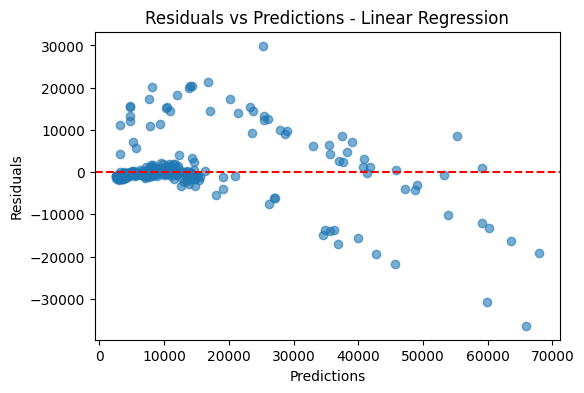

In [ ]:
# Linear Regression
plt.figure(figsize=(6,4))
plt.scatter(y_pred_regression, residuals_linear, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions - Linear Regression")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

<h4> Interprétation des résultats</h4>

Le graphique des résidus montre que la majorité des points sont centrés autour de zéro avec quelques points dispersés, ce qui indique que le modèle de régression linéaire prédit correctement une grande partie des observations.

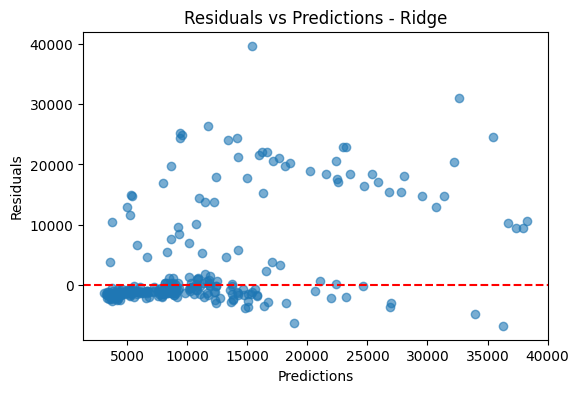

In [ ]:
# Ridge
plt.figure(figsize=(6,4))
plt.scatter(y_pred_Ridge, residuals_ridge, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions - Ridge")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

<h4> Interprétation des résultats </h4>
 Le modèle de régression Ridge parvient à suivre la tendance générale des données, car les résidus restent globalement centrés autour de zéro, ce qui traduit une cohérence dans les prédictions. Même si la dispersion augmente avec des valeurs plus élevées, on observe que la majorité des points restent proches de la ligne de référence, ce qui confirme que le modèle capture correctement la dynamique de croissance des charges dans l'ensemble.

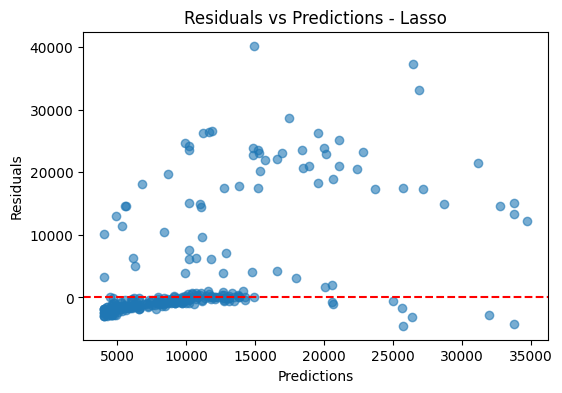

In [ ]:
# Lasso
plt.figure(figsize=(6,4))
plt.scatter(y_pred_lasso, residuals_lasso, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions - Lasso")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

<h4> Interprétation des résultats </h4>
Le modèle de régression Lasso parvient à suivre la tendance générale des données, car les résidus restent globalement centrés autour de zéro, ce qui traduit une cohérence dans les prédictions. Même si la dispersion augmente avec des valeurs plus élevées, on observe que la majorité des points restent proches de la ligne de référence, ce qui confirme que le modèle capture correctement la dynamique de croissance des charges dans l'ensemble.

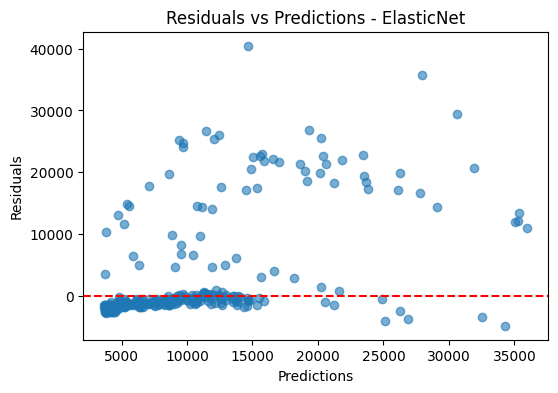

In [ ]:
# ElasticNet
plt.figure(figsize=(6,4))
plt.scatter(y_pred_ElasticNet, residuals_elastic, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predictions - ElasticNet")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()

<h4> Interprétation des résultats</h4>
Le modèle de régression ElasticNet parvient à suivre la tendance générale des données, car les résidus restent globalement centrés autour de zéro, ce qui traduit une cohérence dans les prédictions. Même si la dispersion augmente avec des valeurs plus élevées, on observe que la majorité des points restent proches de la ligne de référence, ce qui confirme que le modèle capture correctement la dynamique de croissance des charges dans l'ensemble.

#### scatter plot des valeurs réelles vs prédites

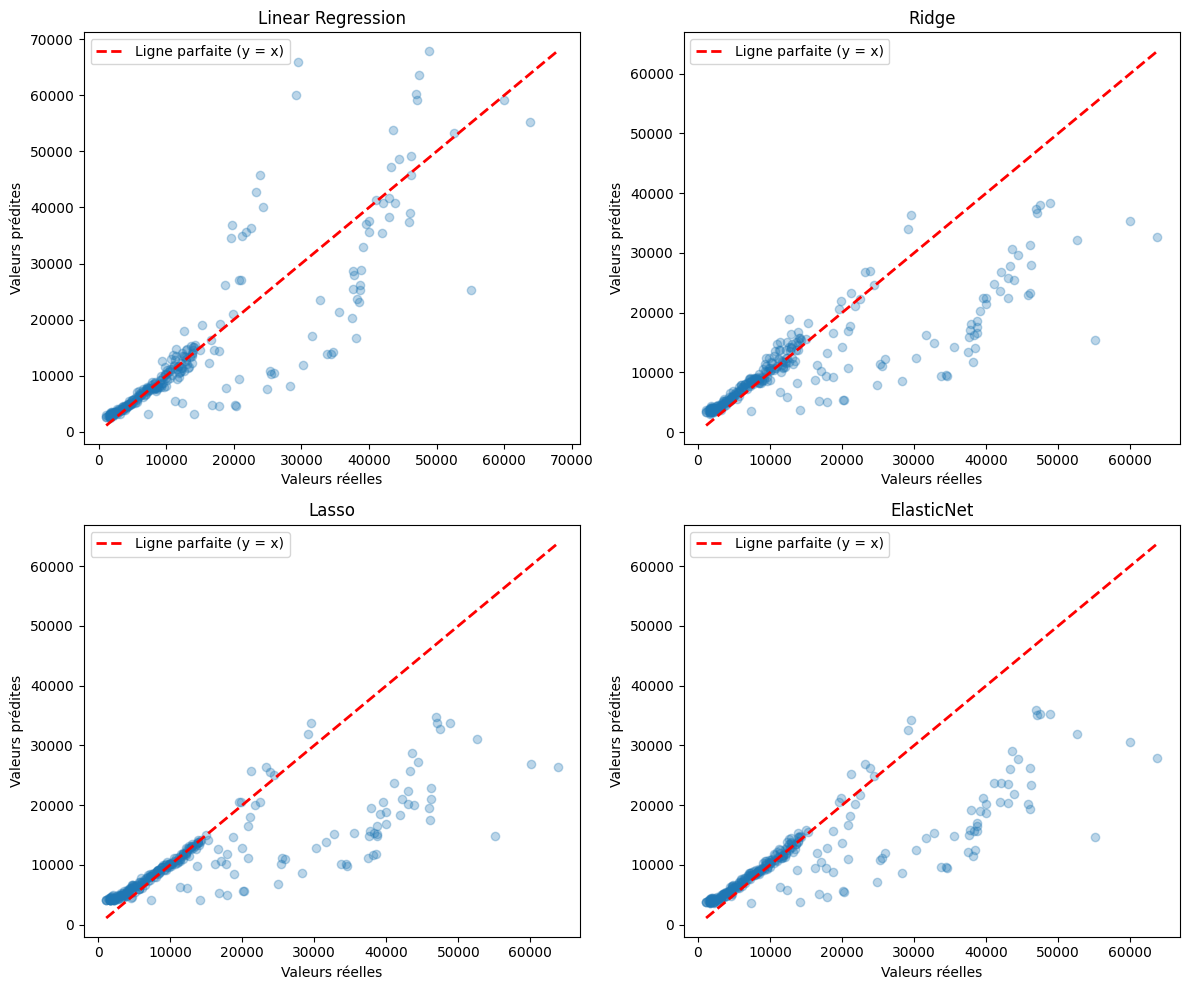

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Liste des modèles et prédictions
models = [
    ("Linear Regression", y_pred_regression),
    ("Ridge", y_pred_Ridge),
    ("Lasso", y_pred_lasso),
    ("ElasticNet", y_pred_ElasticNet)
]

# Boucle pour tracer
for ax, (name, preds) in zip(axes.flatten(), models):

    ax.scatter(y_test_original, preds, alpha=0.3)

    # Ligne parfaite
    min_val = min(y_test_original.min(), preds.min())
    max_val = max(y_test_original.max(), preds.max())
    ax.plot([min_val, max_val],
            [min_val, max_val],
            'r--', linewidth=2, label="Ligne parfaite (y = x)")

    ax.set_title(name)
    ax.set_xlabel("Valeurs réelles")
    ax.set_ylabel("Valeurs prédites")
    ax.legend()

plt.tight_layout()
plt.show()

<h4> Interprétation des résultats</h4>

<b> Lecture par modèle </b> <br>

Linear Regression : bon alignement sur les petites valeurs, mais des erreurs plus fortes sur les valeurs élevées.

Ridge : comportement très similaire à la régression linéaire, avec une légère régularisation qui stabilise un peu les prédictions.

Lasso : résultat proche, avec une dispersion comparable .

ElasticNet : également similaire, sans amélioration visuelle nette par rapport aux autres.  

<b> Conclusion : </b>  Les performances des quatre modèles paraissent assez proches visuellement, sans différence très marquée. Ils capturent bien la tendance globale, mais ils restent moins précis sur les prix élevés et semblent manquer de capacité pour modéliser toute la complexité des données.

###7.3 Tableau Comparatif

In [ ]:
#Transformer la liste en Tableau comparatif des métriques (DataFrame)
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R²", "Adjusted_R²", "MAPE"
])

print(results_df)

               Model          MAE         RMSE        R²  Adjusted_R²  \
0  Linear Regression  3755.924576  7197.032607  0.718119     0.709413   
1              Ridge  4970.864303  8805.732398  0.578023     0.564988   
2              Lasso  5195.270954  9716.109364  0.486260     0.470392   
3         ElasticNet  5080.680948  9385.815534  0.520595     0.505787   

        MAPE  
0  26.165136  
1  36.463433  
2  39.536441  
3  37.473373  


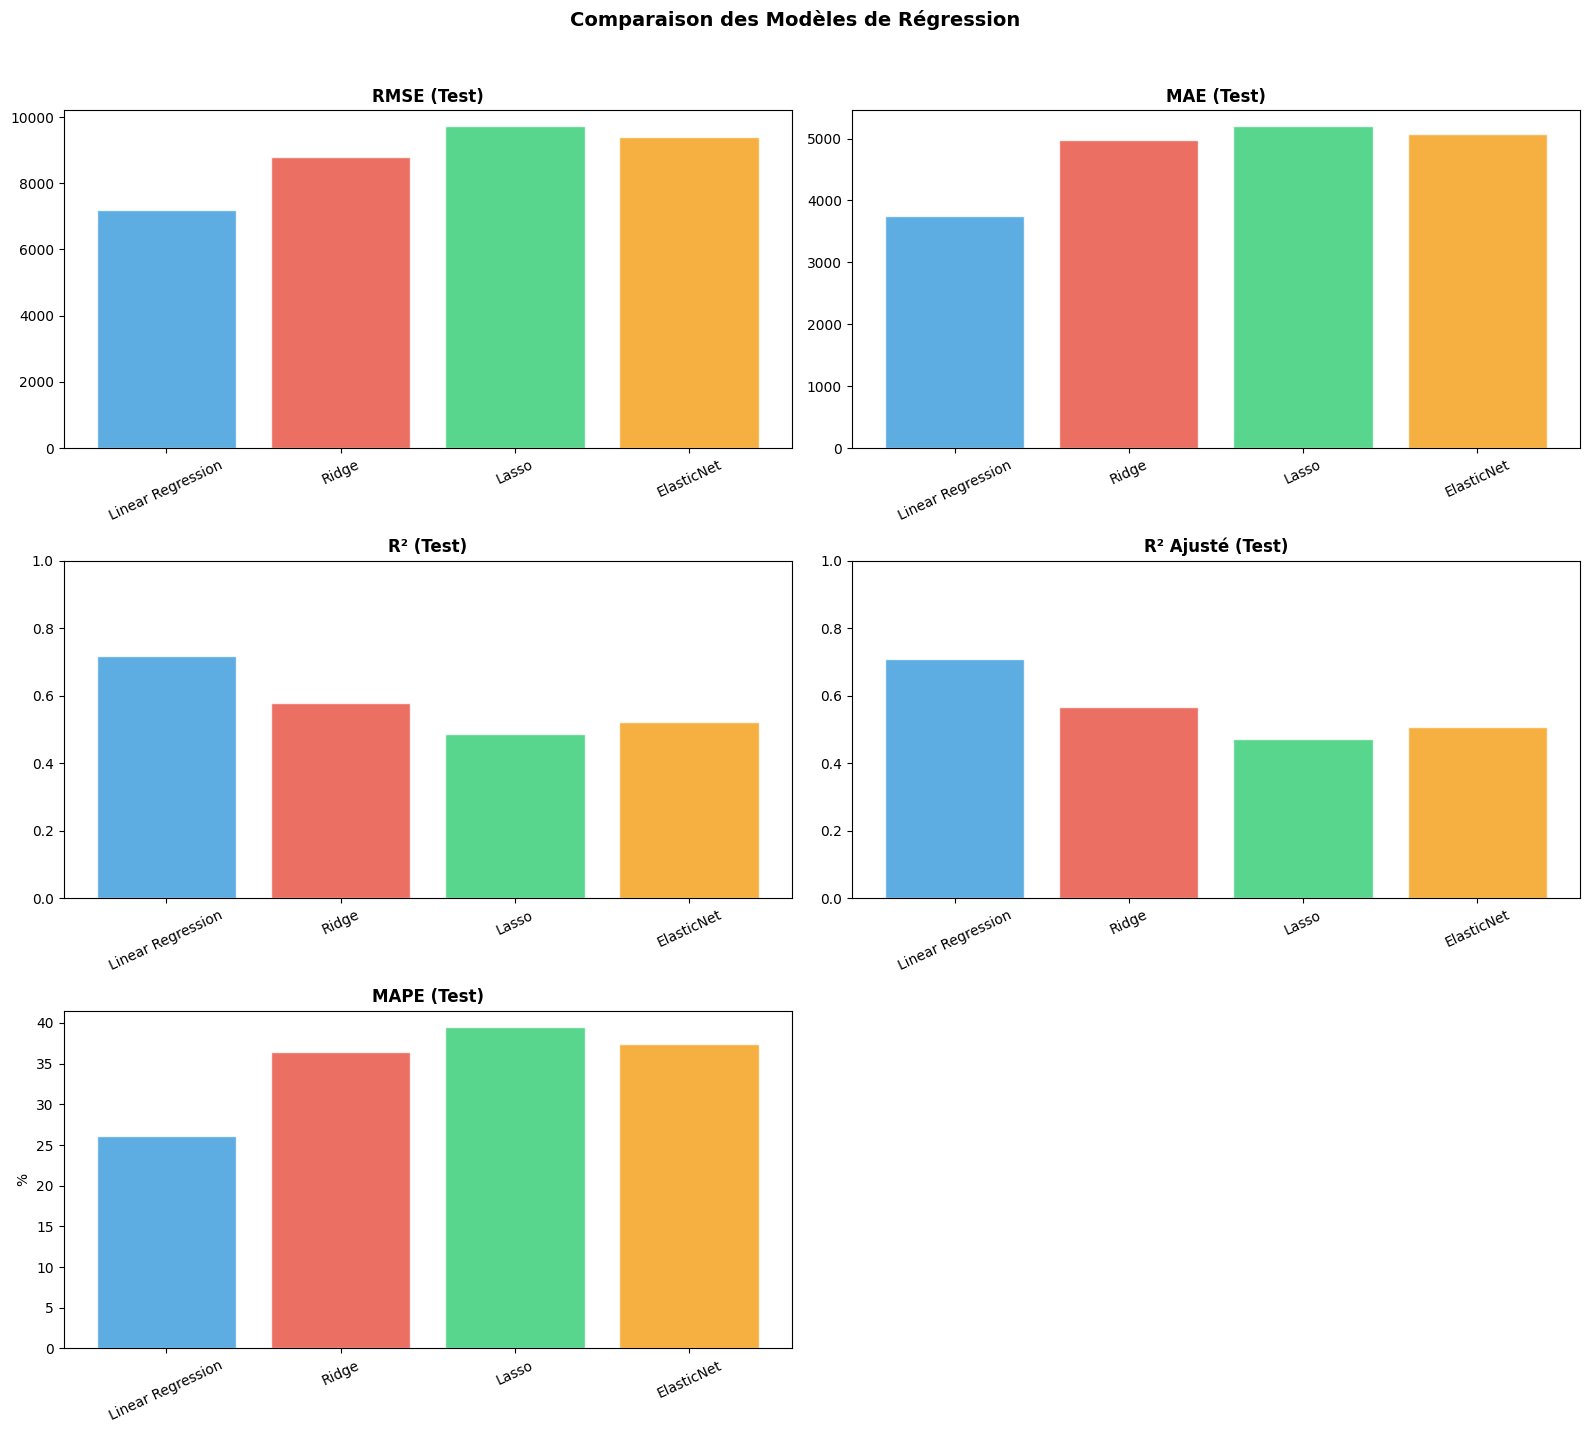

In [ ]:
#  Visualisation comparative

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

models = results_df["Model"]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# =========================
# RMSE
# =========================
axes[0,0].bar(models, results_df["RMSE"], color=colors, alpha=0.8, edgecolor='white')
axes[0,0].set_title('RMSE (Test)', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=25)

# =========================
# MAE
# =========================
axes[0,1].bar(models, results_df["MAE"], color=colors, alpha=0.8, edgecolor='white')
axes[0,1].set_title('MAE (Test)', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=25)

# =========================
# R²
# =========================
axes[1,0].bar(models, results_df["R²"], color=colors, alpha=0.8, edgecolor='white')
axes[1,0].set_title('R² (Test)', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=25)
axes[1,0].set_ylim(0, 1)

# =========================
# Adjusted R²
# =========================
axes[1,1].bar(models, results_df["Adjusted_R²"], color=colors, alpha=0.8, edgecolor='white')
axes[1,1].set_title('R² Ajusté (Test)', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=25)
axes[1,1].set_ylim(0, 1)

# =========================
# MAPE (NOUVEAU)
# =========================
axes[2,0].bar(models, results_df["MAPE"], color=colors, alpha=0.8, edgecolor='white')
axes[2,0].set_title('MAPE (Test)', fontweight='bold')
axes[2,0].tick_params(axis='x', rotation=25)
axes[2,0].set_ylabel('%')

# =========================
# Vide ou suppression du dernier subplot
# =========================
axes[2,1].axis('off')

# =========================
# Titre général
# =========================
plt.suptitle("Comparaison des Modèles de Régression", fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

<h4> Comparaison et interprétation des résultats </h4>

Les résultats montrent que le modèle de <b> régression linéaire simple </b> obtient les meilleures performances globales par rapport aux modèles régularisés (Ridge, Lasso et ElasticNet). Il atteint un coefficient de détermination R²=0.718, ce qui signifie qu'il explique environ 71,8 % de la variance des charges médicales, avec les erreurs les plus faibles (RMSE = 7197, MAE = 3755 et MAPE = 26 %). En comparaison, les modèles Ridge, Lasso et ElasticNet présentent des performances inférieures avec des R² plus faibles et des erreurs plus élevées.

<h4> Identification du meilleur modèle </h4>

 <b> La régression linéaire simple est identifiée comme le meilleur modèle. </b>

## 8. Sélection de Features (Feature Selection)

### 8.1 Backward Elimination

In [ ]:
def backward_elimination(X, y, significance_level=0.05, verbose=True):
    features = list(X.columns)
    history = []
    step = 0

    while True:
        step += 1

        # OLS model (régression linéaire classique)
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()

        # p-values sans constante
        pvalues = model.pvalues.drop('const')

        # 🔥 stocker TOUTES les p-values à cette étape
        history.append({
            "Step": step,
            "Features": features.copy(),
            "PValues": pvalues.to_dict(),
            "R2": model.rsquared,
            "Adj_R2": model.rsquared_adj,
            "Removed": None
        })

        max_pvalue = pvalues.max()
        worst_feature = pvalues.idxmax()

        if verbose:
            print("\n" + "="*60)
            print(f"📌 ÉTAPE {step}")
            print("="*60)
            print(f"Features: {len(features)}")
            print(f"R²: {model.rsquared:.4f}")
            print(f"Adj R²: {model.rsquared_adj:.4f}")
            print(pvalues)
            print(f"Max p-value: {max_pvalue:.6f} ({worst_feature})")

        if max_pvalue > significance_level:
            if verbose:
                print(f"❌ Suppression de '{worst_feature}'")

            features.remove(worst_feature)

            # enregistrer suppression dans la dernière entrée
            history[-1]["Removed"] = worst_feature

        else:
            if verbose:
                print("✅ Toutes les p-values ≤ seuil → STOP")
            break

    return features, history, model

In [ ]:
print("🚀 Lancement Backward Elimination")

selected_features, be_history, final_model = backward_elimination(
    X_train,
    y_train,
    significance_level=0.05,
    verbose=True
)

🚀 Lancement Backward Elimination

📌 ÉTAPE 1
Features: 8
R²: 0.7497
Adj R²: 0.7478
age                 4.053435e-170
bmi                  7.459955e-08
children             7.567975e-17
sex_male             6.258990e-03
smoker_yes          8.333827e-240
region_northwest     2.768716e-01
region_southeast     1.640129e-03
region_southwest     1.201222e-02
dtype: float64
Max p-value: 0.276872 (region_northwest)
❌ Suppression de 'region_northwest'

📌 ÉTAPE 2
Features: 7
R²: 0.7494
Adj R²: 0.7477
age                 3.166568e-170
bmi                  8.598067e-08
children             8.776044e-17
sex_male             6.154350e-03
smoker_yes          2.087633e-240
region_southeast     2.572012e-03
region_southwest     2.278902e-02
dtype: float64
Max p-value: 0.022789 (region_southwest)
✅ Toutes les p-values ≤ seuil → STOP


#### Tableau des p-values à chaque itération

In [ ]:
#Création et affichage du tableau des p-values par itération
rows = []

for h in be_history:
    row = {
        "Step": h["Step"],
        "R2": h["R2"],
        "Adj_R2": h["Adj_R2"],
        "Removed": h["Removed"]
    }

    for feat, pval in h["PValues"].items():
        row[feat] = pval

    rows.append(row)

df_pvalues = pd.DataFrame(rows)

df_pvalues

,Step,R2,Adj_R2,Removed,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,1,0.749653,0.747764,region_northwest,4.053435e-170,7.459955e-08,7.567975e-17,0.006259,8.333827e-240,0.276872,0.001640,0.012012
1,2,0.749373,0.747720,None,3.166568e-170,8.598067e-08,8.776044e-17,0.006154,2.087633e-240,NaN,0.002572,0.022789


#### Liste des features éliminées et celles retenues

In [ ]:
# Features sélectionnées vs éliminées
print(f"\n✅ Features RETENUES ({len(selected_features)}) :")
for f in selected_features:
    print(f"  ✓ {f}")

eliminated_features = [c for c in X_train.columns if c not in selected_features]
print(f"\n❌ Features ÉLIMINÉES ({len(eliminated_features)}) :")
for f in eliminated_features:
    print(f"  ✗ {f}")


✅ Features RETENUES (7) :
  ✓ age
  ✓ bmi
  ✓ children
  ✓ sex_male
  ✓ smoker_yes
  ✓ region_southeast
  ✓ region_southwest

❌ Features ÉLIMINÉES (1) :
  ✗ region_northwest


### 8.2 RFE

In [ ]:
model = LinearRegression()

n_features_list = list(range(1, X_train.shape[1] + 1))
scores = []

for n in n_features_list:
    rfe = RFE(estimator=model, n_features_to_select=n)
    X_rfe = rfe.fit_transform(X_train, y_train)

    # validation croisée
    score = cross_val_score(model, X_rfe, y_train, cv=5, scoring='r2').mean()
    scores.append(score)

# meilleur nombre de features
optimal_n = n_features_list[np.argmax(scores)]

print(f"✅ Nombre optimal de features : {optimal_n}")

✅ Nombre optimal de features : 7


### 8.3 Analyse Lasso

In [ ]:
#Identifier les variables supprimées automatiquement par Lasso
coefficients = lasso_model.coef_
features = X_train.columns
lasso_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
})
zero_features = lasso_df[lasso_df["Coefficient"] == 0]
non_zero_features = lasso_df[lasso_df["Coefficient"] != 0]
print("❌ Features supprimées par Lasso (coef = 0) :")
display(zero_features)

print("\n✅ Features importantes (coef ≠ 0) :")
display(non_zero_features)

❌ Features supprimées par Lasso (coef = 0) :


,Feature,Coefficient
1,bmi,0.0
3,sex_male,-0.0
5,region_northwest,-0.0
6,region_southeast,0.0
7,region_southwest,-0.0



✅ Features importantes (coef ≠ 0) :


,Feature,Coefficient
0,age,0.382906
2,children,0.029034
4,smoker_yes,0.891251


<h4> Justification de la sélection finale des features </h4>
La sélection finale des variables est réalisée à l'aide de l'algorithle de sélection de variables (Backward Elimination) , une méthode statistique basée sur les p-values issues d'un modèle OLS. Cette approche consiste à supprimer progressivement les variables non significatives afin de conserver uniquement celles qui ont un impact statistiquement pertinent sur la variable cible. Les variables retenues représentent les facteurs les plus influents dans la prédiction des charges médicales, notamment le statut de fumeur, l'âge et le nombre d'enfants.

<h4> Explication de l'algorithme de sélection de variables : Backword Elimination </h4>

📌 Principe : <br>

Le Backward Elimination est une méthode de sélection de variables qui consiste à partir de toutes les variables explicatives, puis à éliminer progressivement les moins significatives sur la base de leurs p-values.

Cette méthode repose sur un modèle de régression linéaire estimé avec OLS (Ordinary Least Squares).

⚙️ Étapes de l'algorithme : <br>
1. Initialisation : <br>
* Considérer toutes les variables explicatives ( X_1, X_2, ..., X_p ) <br>
2. Ajustement du modèle <br>
* Ajuster un modèle de régression linéaire avec toutes les variables <br>
* Calculer les p-values associées à chaque coefficient
3. Identification de la variable la moins significative <br>
* Trouver la variable ayant la plus grande p-value <br>
4. Test de significativité <br>
* Si la p-value maximale est supérieure au seuil (ex: α = 0.05)  <br>
→ supprimer cette variable <br>
5. Itération <br>
Répéter les étapes 2 à 4 jusqu'à ce que toutes les p-values soient ≤ au seuil <br>
6. Arrêt <br>
Le processus s'arrête lorsque toutes les variables restantes sont statistiquement significatives <br>

🎯 Critère de décision :

Si $p\text{-value} > \alpha$ → variable non significative ❌  
Si $p\text{-value} \le \alpha$ → variable significative ✅ <br>
#### Avantages :
- ✅ Simple à comprendre et à implémenter
- ✅ Basé sur des tests statistiques rigoureux
- ✅ Réduit le risque d'overfitting

#### Inconvénients :
- ⚠️ Peut manquer des interactions entre variables
- ⚠️ Ordre de suppression peut affecter le résultat final
- ⚠️ Ne convient pas aux données à très grande dimension
#### Conclusion :

Le Backward Elimination est une méthode efficace de sélection de variables permettant de construire un modèle plus simple, tout en conservant uniquement les variables statistiquement significatives.

## 9. Comparaison All Features vs Selected Features

#### Ré-entraînement des modèles (Linear Regression, Ridge, Lasso, ElasticNet) avec les features sélectionnées uniquement

In [ ]:
# Features sélectionnées (déjà standardisées)
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
# 🔵 Linear Regression
lr = LinearRegression()
lr.fit(X_train_sel, y_train)
y_pred_lr = np.expm1(lr.predict(X_test_sel))

In [ ]:
# 🔵 Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sel, y_train)
y_pred_ridge = np.expm1(ridge.predict(X_test_sel))

# 🔵 Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_sel, y_train)
y_pred_lasso = np.expm1(lasso.predict(X_test_sel))

# 🔵 ElasticNet
elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_sel, y_train)
y_pred_elastic = np.expm1(elastic.predict(X_test_sel))

#### Calcul de toutes les métriques d'évaluation (RMSE, MAE, R², Adj. R²)

In [ ]:
def compute_metrics(y_true, y_pred, X):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    n = X.shape[0]
    p = X.shape[1]

    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    # ✅ MAPE (avec sécurité division par zéro)
    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))
    ) * 100

    return mae, rmse, r2, adj_r2, mape

In [ ]:
resultats = []

models_preds = {
    "Linear Regression": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso,
    "ElasticNet": y_pred_elastic
}

for name, y_pred in models_preds.items():
    mae, rmse, r2, adj_r2, mape = compute_metrics(
        y_test_original,
        y_pred,
        X_test_sel
    )

    resultats.append([name, mae, rmse, r2, adj_r2, mape])

In [ ]:
resultats_df = pd.DataFrame(resultats, columns=[
    "Model", "MAE", "RMSE", "R2", "Adjusted_R2", "MAPE"
])

print(resultats_df)

               Model          MAE         RMSE        R2  Adjusted_R2  \
0  Linear Regression  3754.579028  7208.925980  0.717187     0.709573   
1              Ridge  3752.061017  7174.738847  0.719863     0.712321   
2              Lasso  3826.540287  7076.233095  0.727502     0.720166   
3         ElasticNet  3803.308677  7023.990773  0.731511     0.724283   

        MAPE  
0  26.137958  
1  26.209830  
2  27.149519  
3  27.011001  


#### Tableau comparatif

In [ ]:
# All Features
results_all = results_df.copy()
results_all.columns = ["Model", "MAE_all", "RMSE_all", "R2_all", "Adj_R2_all", "MAPE_all"]

# Selected Features
results_sel = resultats_df.copy()
results_sel.columns = ["Model", "MAE_sel", "RMSE_sel", "R2_sel", "Adj_R2_sel", "MAPE_sel"]
#Fusionner les deux tableaux
comparison_df = pd.merge(results_all, results_sel, on="Model")
#Afficher le résultat
comparison_df = comparison_df.round(3)
print(comparison_df)

               Model   MAE_all  RMSE_all  R2_all  Adj_R2_all  MAPE_all  \
0  Linear Regression  3755.925  7197.033   0.718       0.709    26.165   
1              Ridge  4970.864  8805.732   0.578       0.565    36.463   
2              Lasso  5195.271  9716.109   0.486       0.470    39.536   
3         ElasticNet  5080.681  9385.816   0.521       0.506    37.473   

    MAE_sel  RMSE_sel  R2_sel  Adj_R2_sel  MAPE_sel  
0  3754.579  7208.926   0.717       0.710    26.138  
1  3752.061  7174.739   0.720       0.712    26.210  
2  3826.540  7076.233   0.728       0.720    27.150  
3  3803.309  7023.991   0.732       0.724    27.011  


#### Graphiques de comparaison

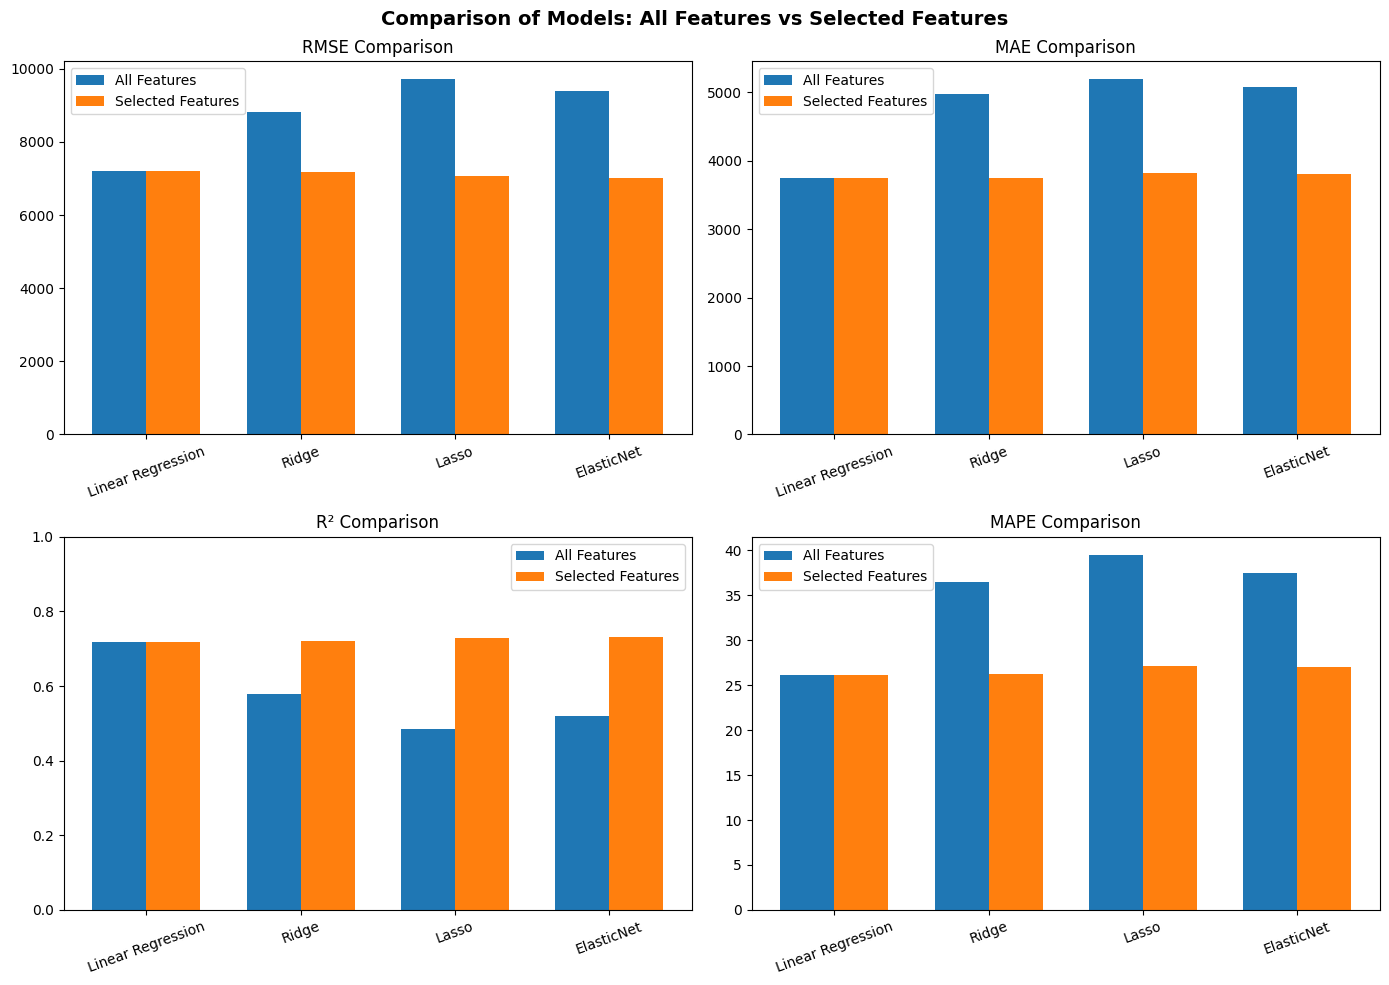

In [ ]:

models = comparison_df["Model"]
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ================= RMSE =================
axes[0,0].bar(x - width/2, comparison_df["RMSE_all"], width, label="All Features")
axes[0,0].bar(x + width/2, comparison_df["RMSE_sel"], width, label="Selected Features")
axes[0,0].set_title("RMSE Comparison")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models, rotation=20)
axes[0,0].legend()

# ================= MAE =================
axes[0,1].bar(x - width/2, comparison_df["MAE_all"], width, label="All Features")
axes[0,1].bar(x + width/2, comparison_df["MAE_sel"], width, label="Selected Features")
axes[0,1].set_title("MAE Comparison")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models, rotation=20)
axes[0,1].legend()

# ================= R2 =================
axes[1,0].bar(x - width/2, comparison_df["R2_all"], width, label="All Features")
axes[1,0].bar(x + width/2, comparison_df["R2_sel"], width, label="Selected Features")
axes[1,0].set_title("R² Comparison")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models, rotation=20)
axes[1,0].set_ylim(0, 1)
axes[1,0].legend()

# ================= MAPE =================
axes[1,1].bar(x - width/2, comparison_df["MAPE_all"], width, label="All Features")
axes[1,1].bar(x + width/2, comparison_df["MAPE_sel"], width, label="Selected Features")
axes[1,1].set_title("MAPE Comparison")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models, rotation=20)
axes[1,1].legend()

plt.suptitle("Comparison of Models: All Features vs Selected Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h4> Analyse et discussion : </h4>

1. Amélioration ou dégradation ? <br>
Les résultats montrent que la sélection de variables a un <b> impact globalement positif sur les modèles. </b> <br>
Pour les modèles régularisés <b> (Ridge, Lasso et ElasticNet) </b> , on observe
une diminution des erreurs (RMSE, MAE et MAPE) et
une augmentation du R².
Cela signifie une <b> amélioration des performances prédictives après sélection des features </b> .
Pour la <b> régression linéaire </b> , <b> les performances restent stables sans changement significatif</b> .
2. Le modèle est-il plus simple sans perte significative de performance ? <br>
Oui, la sélection de features permet de
réduire le nombre de variables utilisées ,
éliminer les variables non significatives et
simplifier la structure des modèles .
Donc, <b> les modèles deviennent plus simples et plus interprétables avec
des performances améliorées . </b>

## 10. Conclusion

#### 1. Résumé des résultats :
1- Meilleur modèle identifié : Régression linéaire simple (OLS - Ordinary Least Squares) <br>
2- Features les plus importantes pour la prédiction : <br>
  ✅ age <br>
  ✅ bmi <br>
  ✅ children <br>
  ✅ sex_male <br>
  ✅ smoker_yes <br>
  ✅ region_southeast <br>
  ✅ region_southwest <br>
#### 2. Observations clés :
1- Impact du statut fumeur sur les charges : Le statut fumeur est la variable la plus influente. Les individus fumeurs présentent des charges médicales nettement plus élevées que les non-fumeurs. Cela s'explique par les risques accrus de maladies liées au tabagisme. <br>
2- Rôle de l'âge et de l'IMC : <br>
* Rôle de l'âge :
L'âge est positivement corrélé avec les charges. Plus une personne est âgée, plus les dépenses médicales augmentent, en raison de la dégradation progressive de la santé. <br>
* Rôle de l'IMC (BMI) :
Un IMC élevé est associé à une augmentation des charges médicales.
 L'obésité peut entraîner des complications de santé nécessitant des soins coûteux.

#### 3. Limites du projet :
1- Taille de la base de données : Le jeu de données utilisé est relativement limité, ce qui peut affecter la capacité du modèle à généraliser sur les données de test . <br>
2- Hypothèses de linéarité : Les modèles utilisés supposent une relation linéaire entre les variables et la cible, ce qui peut ne pas refléter la réalité complexe des données médicales . <br>
3- Variables manquantes potentielles : Certaines variables importantes ne sont pas prises en compte, comme les habitudes alimentaires , les activités physiques et l'historique médical . <br>
#### 4. Perspectives d'amélioration :
1- Modèles non-linéaires (Decision Tree, Random Forest, XGBoost)
<br>

  



In [ ]:
# Modèle Decision tree
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entraînement sur y (log)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [ ]:
y_pred_test_log = dt_model.predict(X_test)

In [ ]:
print(y_pred_test_log[:10])

[ 9.2442065   9.06761726  9.2442065  10.57613219  8.56630334  9.2442065
 10.64856455  7.59437207  9.01165926  9.2442065 ]


In [ ]:
# Conversion vers l’échelle réelle
y_pred_test_real = np.expm1(y_pred_test_log)

In [ ]:
print(y_pred_test_real[:10])

[10343.46117919  8668.94092704 10343.46117919 39187.24827954
  5250.68019857 10343.46117919 42131.07281514  1985.98178056
  8197.11281871 10343.46117919]


In [ ]:
# 2. MAE
# =========================
mae = mean_absolute_error(y_test_original, y_pred_test_real)

# =========================
# 3. RMSE
# =========================
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_real))

# =========================
# 4. R²
# =========================
r2 = r2_score(y_test_original, y_pred_test_real)

# =========================
# 5. Adjusted R²
# =========================
n = X_test.shape[0]      # nombre d'échantillons
p = X_test.shape[1]      # nombre de features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# =========================
# 6. MAPE
# =========================
mape = np.mean(np.abs((y_test_original - y_pred_test_real) / y_test_original)) * 100

# =========================
# 7. Affichage
# =========================
print("📊 Évaluation du modèle Decision Tree")

print(f"\nMAE          : {mae:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adjusted_r2:.4f}")
print(f"MAPE (%)     : {mape:.2f}")

📊 Évaluation du modèle Decision Tree

MAE          : 2079.49
RMSE         : 4304.04
R²           : 0.8992
Adjusted R²  : 0.8961
MAPE (%)     : 18.06


Les résultats obtenus montrent que le modèle présente de bonnes performances globales avec un R² proche de 0.90, indiquant une forte capacité explicative. Cependant, certaines erreurs importantes sont observées, comme le montre la valeur du RMSE, ce qui suggère la présence de cas difficiles à prédire, notamment pour les charges élevées.

In [ ]:
# Modèle Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,   # nombre d'arbres
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# entraînement sur log
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
y_pred_test_rf = rf_model.predict(X_test)
print(y_pred_test_rf[:10])

[ 9.12506432  8.89567005  9.38346113 10.63911419  8.59054492  9.17775944
 10.55575247  7.70662867  9.11144515  9.27676106]


In [ ]:
# Conversion vers l’échelle réelle
y_pred_test_real_rf = np.expm1(y_pred_test_rf)
print(y_pred_test_real_rf[:10])

[ 9181.58762151  7299.29510539 11889.09673445 41734.78467984
  5379.54481862  9678.44104884 38396.68582617  2222.03501682
  9057.37614466 10685.76203506]


In [ ]:
# 2. MAE
# =========================
mae = mean_absolute_error(y_test_original, y_pred_test_real_rf)

# =========================
# 3. RMSE
# =========================
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_real_rf))

# =========================
# 4. R²
# =========================
r2 = r2_score(y_test_original, y_pred_test_real_rf)

# =========================
# 5. Adjusted R²
# =========================
n = X_test.shape[0]      # nombre d'échantillons
p = X_test.shape[1]      # nombre de features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# =========================
# 6. MAPE
# =========================
mape = np.mean(np.abs((y_test_original - y_pred_test_real_rf) / y_test_original)) * 100

# =========================
# 7. Affichage
# =========================
print("📊 Évaluation du modèle Decision Tree")

print(f"\nMAE          : {mae:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adjusted_r2:.4f}")
print(f"MAPE (%)     : {mape:.2f}")

📊 Évaluation du modèle Decision Tree

MAE          : 2065.68
RMSE         : 4356.02
R²           : 0.8967
Adjusted R²  : 0.8935
MAPE (%)     : 19.64


Le modèle Decision Tree présente de bonnes performances globales avec un R² proche de 0.90. Cependant, l'erreur mesurée par RMSE et MAPE montre que certaines prédictions restent imprécises.

In [ ]:
#Modèle XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# entraînement sur log(charges)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_test_xg = xgb_model.predict(X_test)
print(y_pred_test_xg[:10])

[ 9.106997  8.840455  9.44121  10.446476  8.45074   9.247417 10.603448
  7.797605  9.206644  9.271452]


In [ ]:
# Conversion vers l’échelle réelle
y_pred_test_real_xg = np.expm1(y_pred_test_xg)
print(y_pred_test_real_xg[:10])

[ 9017.168   6907.1357 12595.947  34421.855   4677.5327 10376.73
 40272.457   2433.764   9962.105  10629.176 ]


In [ ]:
# 2. MAE
# =========================
mae = mean_absolute_error(y_test_original, y_pred_test_real_xg)

# =========================
# 3. RMSE
# =========================
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test_real_xg))

# =========================
# 4. R²
# =========================
r2 = r2_score(y_test_original, y_pred_test_real_xg)

# =========================
# 5. Adjusted R²
# =========================
n = X_test.shape[0]      # nombre d'échantillons
p = X_test.shape[1]      # nombre de features

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# =========================
# 6. MAPE
# =========================
mape = np.mean(np.abs((y_test_original - y_pred_test_real_xg) / y_test_original)) * 100

# =========================
# 7. Affichage
# =========================
print("📊 Évaluation du modèle Decision Tree")

print(f"\nMAE          : {mae:.2f}")
print(f"RMSE         : {rmse:.2f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adjusted_r2:.4f}")
print(f"MAPE (%)     : {mape:.2f}")

📊 Évaluation du modèle Decision Tree

MAE          : 2543.84
RMSE         : 5023.19
R²           : 0.8627
Adjusted R²  : 0.8584
MAPE (%)     : 20.25


2- Feature Engineering (interactions, transformations polynomiales) : <br>
Interactions: c'est transformer les données brutes en nouvelles variables qui représentent l'effet combiné de deux variables pour aider le modèle à mieux apprendre. <br>
Transformations polynomiales: On ajoute des puissances d'une variable pour capturer des relations non linéaires.

3- Collecte de données supplémentaires : <br>
La collecte de données supplémentaires (data collection) consiste à augmenter la base de données avec de nouvelles observations ou variables afin d'améliorer la qualité et la performance du modèle IA.
